<a href="https://colab.research.google.com/github/aislam2346/aislam/blob/main/NYC_Taxi_Drift_Pipeline_FINAL_SUBMISSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NYC Taxi Drift Detection Pipeline


Follow the instructions below and if you would like to run the code, please ensure `final_scripts\` folder is within your Google Drive.

This pipeline relies on raw taxi parquet files to exist within the
`nyc_taxi_parquet_files` folder. To download raw parquet files, please refer to the https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

## How to Run

**First session (fresh start):**
1. Run **Section 1** — install packages, mount Drive, load config
2. Run **Section 2** — Run the main pipeline, stepping through from stages 1 to 5.

**Main Pipeline Stages:**
1. Run ETL Pipeline (incremental, no need to run if all files are processed to gold)
2. Prepare datasets and feature engineering (if this step is already done, read from cached file for e.g. features_2019-01_to_2020-01.parquet)
3. Baseline Modelling (if this step is already done, read from cached pkl file for e.g. model_baseline_2019.pkl)
4. Detect Covariate Drifts
4. Detect Concept Drifts

**Force rebuild any step:**
- ETL: `run_etl_pipeline(force_reprocess=True)`
- Features: `run_feature_engineering(..., force_reprocess=True)`


**Input and Output files (all saved to Google Drive):**
| Directory | Contents |
|---|---|
| `nyc_taxi_parquet_files/` | Raw NYC Taxi files |
| `gold/` | Monthly curated parquets (ETL output) |
| `features/` | Feature-engineered parquets |
| `models/` | Trained LightGBM model + metadata |
| `predictions/` | 2020 holdout predictions with residuals |
| `drift_outputs/` | Covariate drift + change point results |
| `baseline_snapshots/` | Reference distribution snapshots |

For more information about how these files are configure please refer `pipeline_config.py` located within the `final_scripts\` folder.

## Section 1: Setup

Run this section at the start of every Colab session.

In [ ]:
# ── 1a. Package installation ──────────────────────────────────────────────────
# Uncomment and run once if packages are not already installed.
#numpy<2.1 is pinned to avoid numba/river compatibility issues in Colab.
# !pip install "numpy<2.1,>=1.22" river --quiet
# !pip install duckdb pyarrow geopandas lightgbm holidays --quiet
print("Packages ready (uncomment above if first install needed)")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 57.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
Packages ready (uncomment above if first install needed)


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import sys
SCRIPTS_DIR = '/content/drive/MyDrive/ODATA57078/final_scripts'
if SCRIPTS_DIR not in sys.path:
    sys.path.insert(0, SCRIPTS_DIR)

from pipeline_config        import *
from etl_pipeline           import *
from feature_engineering    import *
from baseline_modelling      import *
from detect_covariate_drift import *
from concept_drift_detection import *

print("All modules loaded")

Mounted at /content/drive


ModuleNotFoundError: No module named 'concept_drift_detection'

## Section 2: Run Main Script

### Step 1: Run ETL Pipeline

In [ ]:
# Run Main Pipeline
# This pipeline assumes that there are raw files in the PARQUET_DIR
# If there are gold curated datasets in the GOLD_DIR for a certain month, then files won't be processed for that month

run_etl_pipeline(months=MONTHS_TO_INGEST,
                 force_reprocess=False,
                 cleaning_config=CLEANING_CONFIG,
                 required_columns=REQUIRED_COLUMNS,
                 rowhash_fields=ROWHASH_FIELDS,
                 airport_location_ids=AIRPORT_LOCATION_IDS)

  Schema bootstrapped (idempotent)
  Skipping 2019-01 — already processed
  Skipping 2019-02 — already processed
  Skipping 2019-03 — already processed
  Skipping 2019-04 — already processed
  Skipping 2019-05 — already processed
  Skipping 2019-06 — already processed
  Skipping 2019-07 — already processed
  Skipping 2019-08 — already processed
  Skipping 2019-09 — already processed
  Skipping 2019-10 — already processed
  Skipping 2019-11 — already processed
  Skipping 2019-12 — already processed
  Skipping 2020-01 — already processed
  Skipping 2020-02 — already processed
  Skipping 2020-03 — already processed
  Skipping 2020-04 — already processed
  Skipping 2020-05 — already processed
  Skipping 2020-06 — already processed
  Skipping 2020-07 — already processed
  Skipping 2020-08 — already processed
  Skipping 2020-09 — already processed
  Skipping 2020-10 — already processed
  Skipping 2020-11 — already processed
  Skipping 2020-12 — already processed
  ETL Complete
  Processed : 

{'processed': [],
 'skipped': ['2019-01',
  '2019-02',
  '2019-03',
  '2019-04',
  '2019-05',
  '2019-06',
  '2019-07',
  '2019-08',
  '2019-09',
  '2019-10',
  '2019-11',
  '2019-12',
  '2020-01',
  '2020-02',
  '2020-03',
  '2020-04',
  '2020-05',
  '2020-06',
  '2020-07',
  '2020-08',
  '2020-09',
  '2020-10',
  '2020-11',
  '2020-12'],
 'failed': []}

As we can see above the ETL pipeline does not reload already processed file. Below is an example of what processing a new file would look like if either the curated dataset does not exist or the watermark record is missing.

In [ ]:
# Test ETL pipeline for processing the first month of 2019

# USED FOR TEMPORARILY REMOVING RECORDS
# wm = _load_watermark_json(watermark_path=WMARK_DIR)
# # First n number of months
# months_to_reprocess = MONTHS_TO_INGEST[:1]
# for month in months_to_reprocess:
#     key = f"gold::yellow_tripdata_{month}.parquet"
#     wm.pop(key, None)
# _save_watermark_json(watermark_path=WMARK_DIR, wm=wm)

# Run the pipeline
# force reprocess can be use to forcibly reproduce gold files even if it already exists
# parameter values chosen below are already the default values so you don't need to include them
run_etl_pipeline(months=MONTHS_TO_INGEST,
                 force_reprocess=False,
                 cleaning_config=CLEANING_CONFIG,
                 required_columns=REQUIRED_COLUMNS,
                 rowhash_fields=ROWHASH_FIELDS,
                 airport_location_ids=AIRPORT_LOCATION_IDS)

  Schema bootstrapped (idempotent)
  Processing: 2019-01
  Memory cleared for 2019-01
  Ingesting raw: yellow_tripdata_2019-01.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Raw  | yellow_tripdata_2019-01.parquet | 7,696,617 rows loaded into TEMP
  Running audit checks for 2019-01...
  [WARNING] Negatives — distance: 0, fare: 7129, total: 7127


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  [WARNING] 2 duplicate trip fingerprints in 2019-01
  Audit complete for 2019-01 — review warnings before proceeding
 Pre-cleaning audit for 2019-01:


...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 Post-cleaning sense check for 2019-01:
  Silver | 2019-01 | 7,287,576 valid rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Gold | 2019-01 | 98,386 hourly zone records → /content/drive/MyDrive/ODATA57078/gold/2019-01.parquet
  Skipping 2019-02 — already processed
  Skipping 2019-03 — already processed
  Skipping 2019-04 — already processed
  Skipping 2019-05 — already processed
  Skipping 2019-06 — already processed
  Skipping 2019-07 — already processed
  Skipping 2019-08 — already processed
  Skipping 2019-09 — already processed
  Skipping 2019-10 — already processed
  Skipping 2019-11 — already processed
  Skipping 2019-12 — already processed
  Skipping 2020-01 — already processed
  Skipping 2020-02 — already processed
  Skipping 2020-03 — already processed
  Skipping 2020-04 — already processed
  Skipping 2020-05 — already processed
  Skipping 2020-06 — already processed
  Skipping 2020-07 — already processed
  Skipping 2020-08 — already processed
  Skipping 2020-09 — already processed
  Skipping 2020-10 — already processed
  Skipping 2020-11 — already processed
  Skipping 2020-12 — already processed


{'processed': ['2019-01'],
 'skipped': ['2019-02',
  '2019-03',
  '2019-04',
  '2019-05',
  '2019-06',
  '2019-07',
  '2019-08',
  '2019-09',
  '2019-10',
  '2019-11',
  '2019-12',
  '2020-01',
  '2020-02',
  '2020-03',
  '2020-04',
  '2020-05',
  '2020-06',
  '2020-07',
  '2020-08',
  '2020-09',
  '2020-10',
  '2020-11',
  '2020-12'],
 'failed': []}

### Step 2: Prepare datasets and apply feature engineering

We will prepare weather data by calling the Open Meteo API if it doesn't already, or if does exist, retrieve from a cached file. Then we will prepare our reference and monitoring datasets for the downstream processes.

In this example, we will train our model on the entirety of 2019 and then test its performance on the first six months of 2020.

The idea is that once degradation patterns are clear during the first six months of 2020, the user is expected to retrain the model.

This can be achieved by retraining the model on new data or using additional, exogenous features such as COVID cases and traffic data in order for the model to successfully operate within the new context.

In [ ]:
df_weather = load_or_fetch_weather(
    weather_path = WEATHER_PATH,
    start_date   = "2019-01-01",
    end_date     = "2021-12-31",
)

reference_data = run_feature_engineering(
    start_date = "2019-01-01", # Start and end dates
    end_date   = "2020-01-01",
    df_weather = df_weather,
    force_reprocess = True, # This will force reprocessing otherwise we retrieve records from a cached file
    boroughs = ["Manhattan", "Queens", "Brooklyn"], # Top three boroughs
    gold_dir = GOLD_DIR, # Where are gold data is located
    feat_dir = FEAT_DIR # Where we will details about our features used later for drift detection and training.
)

monitoring_data = run_feature_engineering(
    start_date = "2020-01-01",
    end_date   = "2020-07-01",
    df_weather = df_weather,
    force_reprocess = True,
    boroughs = ["Manhattan", "Queens", "Brooklyn"],
    gold_dir = GOLD_DIR,
    feat_dir = FEAT_DIR
)

  Weather loaded from cache — 26,304 rows
  Feature Engineering: 2019-01-01 → 2020-01-01
  Boroughs: ['Manhattan', 'Queens', 'Brooklyn']
  Loading: 2018-12 → 2020-01 (+7d warmup)
  [WARNING] Missing gold months: ['2018-12']
  Gold loaded: 1,060,133 rows
  Weather joined — 5 columns added
  Zone info joined — zone, borough, service_zone, zone_area_km2 added
  Borough filter: 1,060,133 → 981,150 rows (198 zones)


/content/drive/MyDrive/ODATA57078/final_scripts/feature_engineering.py:280: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.ffill().bfill()))


  Lag features built — 1,734,678 rows | 33,264 NaN lag_168h rows (warmup — dropped in prepare_features)
  Dropped 33,264 NaN rows (warmup + leading weather) — 1,701,414 remain
  Features prepared — 1,701,414 rows, 19 features
    Saved → features_2019-01_to_2020-01.parquet
    Rows: 1,701,414 | Cols: 37
    Range: 2019-01-08 00:00:00 → 2020-01-01 00:00:00
    Zones: 198
  Feature Engineering: 2020-01-01 → 2020-07-01
  Boroughs: ['Manhattan', 'Queens', 'Brooklyn']
  Loading: 2019-12 → 2020-07 (+7d warmup)
  Gold loaded: 351,516 rows
  Weather joined — 5 columns added
  Zone info joined — zone, borough, service_zone, zone_area_km2 added
  Borough filter: 351,516 → 335,180 rows (197 zones)


/content/drive/MyDrive/ODATA57078/final_scripts/feature_engineering.py:280: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.ffill().bfill()))


  Lag features built — 893,789 rows | 33,096 NaN lag_168h rows (warmup — dropped in prepare_features)
  Dropped 33,096 NaN rows (warmup + leading weather) — 860,693 remain
  Features prepared — 860,693 rows, 19 features
    Saved → features_2020-01_to_2020-07.parquet
    Rows: 860,693 | Cols: 37
    Range: 2020-01-01 00:00:00 → 2020-07-01 00:00:00
    Zones: 197


Let's preview our datasets for a quick sense check.

In [ ]:
reference_data.head()

,PULocationID,pickup_hour_ts,file_month,trip_count,pct_card_payment,pct_cash_payment,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,...,lag_168h,lag_1h_log,lag_24h_log,lag_168h_log,pct_card_payment_lag_1h,pct_cash_payment_lag_1h,avg_trip_distance_lag_1h,avg_fare_amount_lag_1h,avg_duration_mins_lag_1h,avg_passenger_count_lag_1h
0,2,2019-01-08 00:00:00,2019-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2019-01-08 01:00:00,2019-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2019-01-08 02:00:00,2019-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2,2019-01-08 03:00:00,2019-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2,2019-01-08 04:00:00,2019-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
monitoring_data.head()

,PULocationID,pickup_hour_ts,file_month,trip_count,pct_card_payment,pct_cash_payment,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,...,lag_168h,lag_1h_log,lag_24h_log,lag_168h_log,pct_card_payment_lag_1h,pct_cash_payment_lag_1h,avg_trip_distance_lag_1h,avg_fare_amount_lag_1h,avg_duration_mins_lag_1h,avg_passenger_count_lag_1h
0,2,2020-01-01 00:00:00,2020-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2020-01-01 01:00:00,2020-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2020-01-01 02:00:00,2020-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2,2020-01-01 03:00:00,2020-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2,2020-01-01 04:00:00,2020-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
monitoring_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860693 entries, 0 to 860692
Data columns (total 37 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   PULocationID                860693 non-null  int32         
 1   pickup_hour_ts              860693 non-null  datetime64[ns]
 2   file_month                  860693 non-null  object        
 3   trip_count                  860693 non-null  float64       
 4   pct_card_payment            860693 non-null  float64       
 5   pct_cash_payment            860693 non-null  float64       
 6   avg_trip_distance           860693 non-null  float64       
 7   avg_fare_amount             860693 non-null  float64       
 8   avg_duration_mins           860693 non-null  float64       
 9   avg_passenger_count         860693 non-null  float64       
 10  hour_of_day                 860693 non-null  category      
 11  day_of_week                 860693 non-

### Step 3: Prepare baseline model and predict on monitoring data

These are the feature we've chosen to be in our baseline model.

In [ ]:
FEATURES

['zone',
 'borough',
 'hour_of_day',
 'day_of_week',
 'month_of_year',
 'pct_cash_payment_lag_1h',
 'avg_duration_mins_lag_1h',
 'avg_passenger_count_lag_1h',
 'lag_1h_log',
 'lag_24h_log',
 'lag_168h_log',
 'is_holiday',
 'is_weekend',
 'is_airport',
 'temperature_2m',
 'precipitation',
 'snowfall',
 'windspeed_10m',
 'zone_area_km2']

Now we will train our baseline model using the rolling window method.

In [ ]:
results = train_baseline_model(
    df            = reference_data,
    features      = FEATURES,
    target        = TARGET,
    categorical_cols = CATEGORICAL_COLS,
    params        = MODEL_PARAMS,
    folds         = BASELINE_FOLDS,
    model_dir     = MODEL_DIR,
    version_label = "baseline_2019",
)

# Load model if not available in global
baseline_model    = results['model']
fold_results      = results['fold_results']
feature_importance= results['feature_importance']
cv_predictions    = results['cv_predictions']

# Save reference distribution snapshot for later comparison
numerical_features = [f for f in FEATURES if f in reference_data.columns and
                      pd.api.types.is_numeric_dtype(reference_data[f])]
save_distribution_snapshot(reference_data, numerical_features,
                           "2019_reference", SNAPSHOT_DIR)

  Training: baseline_2019
  Data range: 2019-01-08 00:00:00 → 2020-01-01 00:00:00
  Rows: 1,701,414 | Features: 19
[200]	valid_0's l1: 6.20472
[400]	valid_0's l1: 4.79772
[600]	valid_0's l1: 4.67334
[800]	valid_0's l1: 4.61369
[1000]	valid_0's l1: 4.57824
[1200]	valid_0's l1: 4.55458
[1400]	valid_0's l1: 4.53316
[1600]	valid_0's l1: 4.51821
[1800]	valid_0's l1: 4.50662
  Fold 1 | train 2019-01→2019-07 | val 2019-08 | MAE 4.51 | MAPE 35.3% | WMAPE 11.6% | iters 1798
[200]	valid_0's l1: 7.52834
[400]	valid_0's l1: 5.82848
[600]	valid_0's l1: 5.66152
[800]	valid_0's l1: 5.5405
[1000]	valid_0's l1: 5.46385
[1200]	valid_0's l1: 5.41472
[1400]	valid_0's l1: 5.37542
[1600]	valid_0's l1: 5.34575
[1800]	valid_0's l1: 5.3176
  Fold 2 | train 2019-02→2019-08 | val 2019-09 | MAE 5.32 | MAPE 35.6% | WMAPE 12.2% | iters 1800
[200]	valid_0's l1: 7.50071
[400]	valid_0's l1: 5.75753
[600]	valid_0's l1: 5.59444
[800]	valid_0's l1: 5.49843
[1000]	valid_0's l1: 5.43617
[1200]	valid_0's l1: 5.39906
[1400]	

Now we will see how our model performs on the data we are monitoring (i.e. 2020 data).

In [ ]:
# Load model if not available in global
baseline_model = load_model(MODEL_DIR, "baseline_2019")

# Predict on monitoring data and append additional details such as residuals
# and predictive error
monitoring_with_preds = predict(
    model      = baseline_model,
    df         = monitoring_data,
    features   = FEATURES,
    target     = TARGET,
    save_path  = PREDICT_DIR / "2020_predictions.parquet",
)

# Read from cached file is not already saved and filter out July data - we are only interested in the first six months.
# monitoring_with_preds = pd.read_parquet(PREDICT_DIR / '2020_predictions.parquet')
monitoring_with_preds = monitoring_with_preds[monitoring_with_preds['pickup_hour_ts'] < '2020-07-01 00:00:00'].copy()

# Evaluate our forecast
holdout_metrics = evaluate_forecast(
    y_true = monitoring_with_preds['trip_count'],
    y_pred = monitoring_with_preds['y_pred'],
    label  = "2020 Holdout (baseline model)"
)

print(f"2020 Holdout WMAPE: {holdout_metrics['wmape']:.1f}%")

  Model loaded: baseline_2019
  Predictions saved → /content/drive/MyDrive/ODATA57078/predictions/2020_predictions.parquet (860,693 rows)
  2020 Holdout (baseline model): MAE=3.09,MAPE=53.4%, WMAPE=16.8%, NMAE=16.8%, Bias=5.6%
2020 Holdout WMAPE: 16.8%


How does the predictive performance look overall on 2020 data? Do we see degradation? Which features were considered important during prediction?


In [ ]:
CB = {
    'actual'     : '#0072B2',   # blue
    'predicted'  : '#009E73',   # teal
    'wmape'      : '#D55E00',   # vermillion
    'covid'      : '#999999',   # grey
    'importance' : '#E69F00',   # orange
    'bg'         : '#f7f7f7',
    'text'       : '#333333',
}


# ── Shared prep ───────────────────────────────────────────────────────────────
df = monitoring_with_preds.copy()
df['pickup_hour_ts'] = pd.to_datetime(df['pickup_hour_ts'])
df['date']  = df['pickup_hour_ts'].dt.date
df['month'] = df['pickup_hour_ts'].dt.to_period('M').astype(str)
COVID_DATE  = '2020-03-01'

boroughs = sorted(df['borough'].astype(str).unique().tolist())
print("Boroughs:", boroughs)  # confirm which three

# ── Daily aggregation ─────────────────────────────────────────────────────────
daily = (
    df.groupby('date')
    .agg(
        actual    = ('trip_count', 'sum'),
        predicted = ('y_pred',     'sum'),
        abs_error = ('abs_error',  'sum'),
    )
    .reset_index()
)
daily['date']  = pd.to_datetime(daily['date'])
daily['wmape'] = daily['abs_error'] / daily['actual'].replace(0, np.nan) * 100

# ── Monthly aggregation ───────────────────────────────────────────────────────
monthly = (
    df.groupby('month')
    .agg(
        actual    = ('trip_count', 'sum'),
        predicted = ('y_pred',     'sum'),
        abs_error = ('abs_error',  'sum'),
    )
    .reset_index()
)
monthly['wmape']      = monthly['abs_error'] / monthly['actual'].replace(0, np.nan) * 100
monthly['month_dt']   = pd.to_datetime(monthly['month'])

# Filter monthly data to exclude July 2020, as monitoring data goes up to June 2020
monthly = monthly[monthly['month'] < '2020-07'].copy()

Boroughs: ['Brooklyn', 'Manhattan', 'Queens']


Plot Actuals vs Predicted, and compare against WMAPE

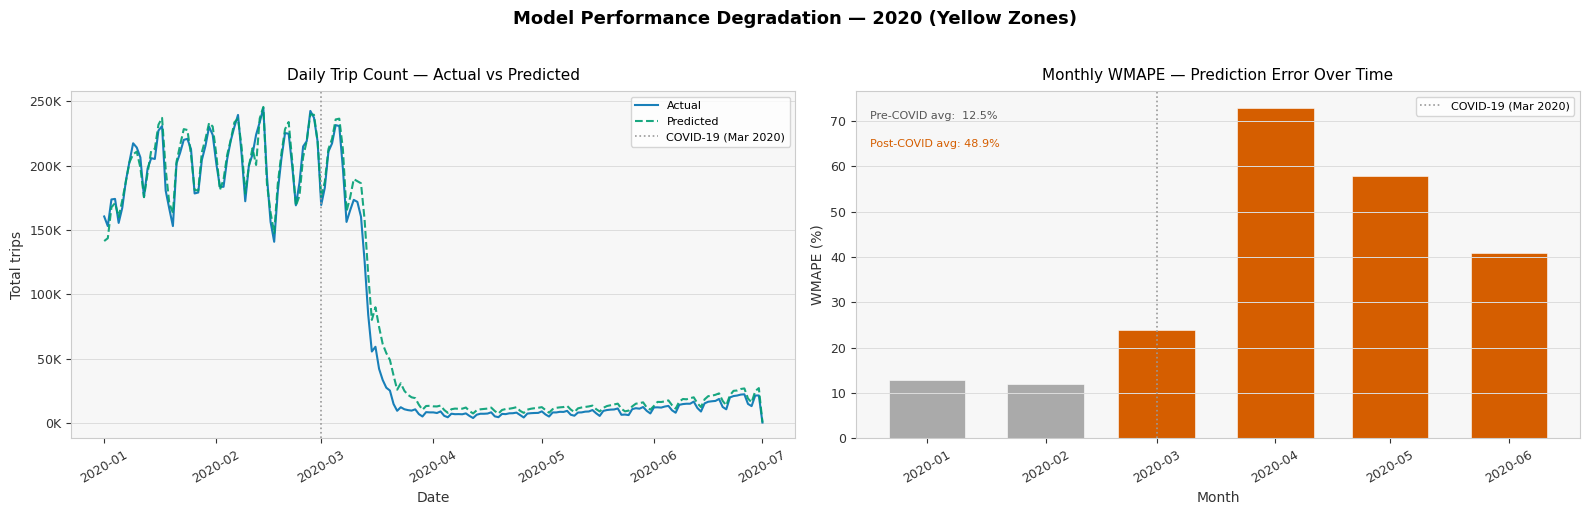

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('white')

for ax in axes:
    ax.set_facecolor('#f7f7f7')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
    ax.tick_params(colors='#333333', labelsize=9)
    ax.xaxis.label.set_color('#333333')
    ax.yaxis.label.set_color('#333333')

# ── Panel A: daily actuals vs predicted ──────────────────────────────────────
ax = axes[0]

ax.plot(daily['date'], daily['actual'],
        color=CB['actual'], linewidth=1.5, label='Actual', alpha=0.9)
ax.plot(daily['date'], daily['predicted'],
        color=CB['predicted'], linewidth=1.5, label='Predicted',
        linestyle='--', alpha=0.9)

ax.axvline(pd.to_datetime(COVID_DATE), color=CB['covid'],
           linewidth=1.2, linestyle=':', label='COVID-19 (Mar 2020)')

ax.set_title('Daily Trip Count — Actual vs Predicted', fontsize=11, pad=8)
ax.set_xlabel('Date')
ax.set_ylabel('Total trips')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.legend(fontsize=8, framealpha=0.8)
ax.grid(axis='y', color='#dddddd', linewidth=0.7)
ax.tick_params(axis='x', rotation=30)

# ── Panel B: monthly WMAPE ───────────────────────────────────────────────────
ax = axes[1]

bar_colours = [
    CB['wmape'] if str(m) >= '2020-03' else '#aaaaaa'
    for m in monthly['month']
]
ax.bar(monthly['month_dt'], monthly['wmape'],
       color=bar_colours, width=20, edgecolor='white', linewidth=0.4)

ax.axvline(pd.to_datetime(COVID_DATE), color=CB['covid'],
           linewidth=1.2, linestyle=':', label='COVID-19 (Mar 2020)')

ax.set_title('Monthly WMAPE — Prediction Error Over Time', fontsize=11, pad=8)
ax.set_xlabel('Month')
ax.set_ylabel('WMAPE (%)')
ax.legend(fontsize=8, framealpha=0.8)
ax.grid(axis='y', color='#dddddd', linewidth=0.7)
ax.tick_params(axis='x', rotation=30)

# Pre/post annotation
pre  = monthly[monthly['month'] <  '2020-03']['wmape'].mean()
post = monthly[monthly['month'] >= '2020-03']['wmape'].mean()
ax.text(0.02, 0.92, f'Pre-COVID avg:  {pre:.1f}%',
        transform=ax.transAxes, fontsize=8, color='#555555')
ax.text(0.02, 0.84, f'Post-COVID avg: {post:.1f}%',
        transform=ax.transAxes, fontsize=8, color=CB['wmape'])

plt.suptitle('Model Performance Degradation — 2020',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'covid_overall.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

Feature Importance Plot

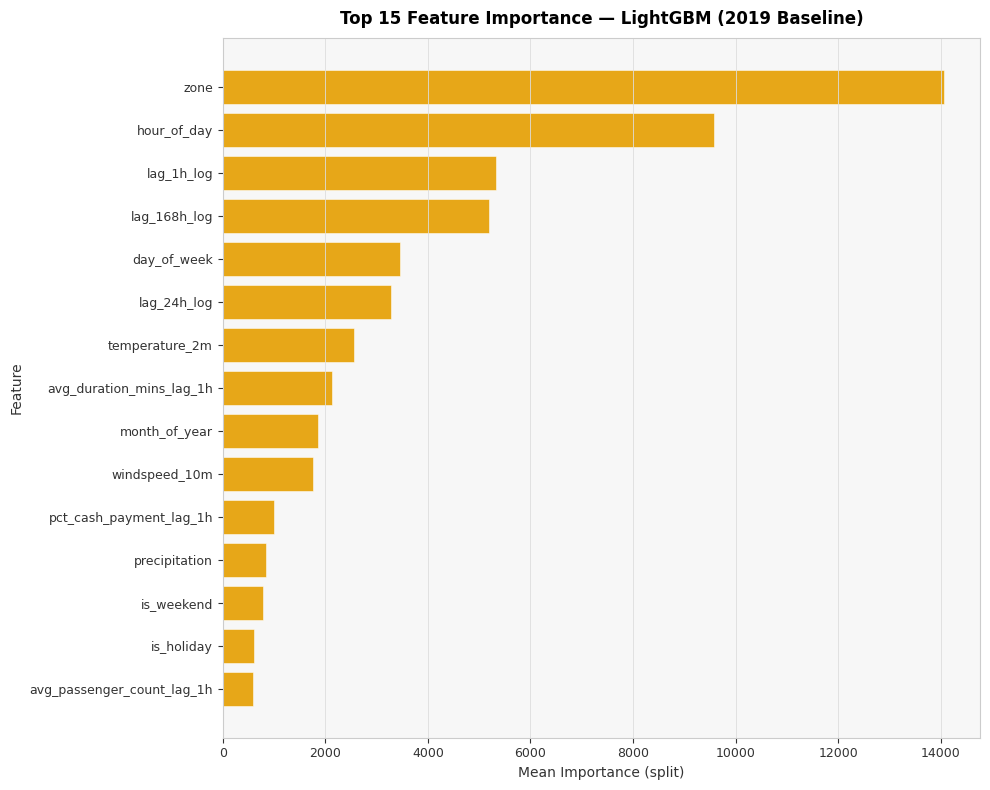


Top 10 Features:
                 feature  importance
                    zone     14065.2
             hour_of_day      9588.8
              lag_1h_log      5333.6
            lag_168h_log      5191.8
             day_of_week      3459.4
             lag_24h_log      3288.6
          temperature_2m      2560.2
avg_duration_mins_lag_1h      2121.6
           month_of_year      1856.2
           windspeed_10m      1756.8


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor(CB['bg'])

for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')

ax.tick_params(colors=CB['text'], labelsize=9)
ax.xaxis.label.set_color(CB['text'])
ax.yaxis.label.set_color(CB['text'])

# Feature importance (already sorted by train_baseline_model)
fi = results['feature_importance'].copy()
top_n = 15  # Show top 15 features

ax.barh(fi['feature'].head(top_n)[::-1],
        fi['importance'].head(top_n)[::-1],
        color=CB['importance'], edgecolor='white', linewidth=0.4, alpha=0.9)

ax.set_xlabel('Mean Importance (split)', fontsize=10)
ax.set_ylabel('Feature', fontsize=10)
ax.set_title('Top 15 Feature Importance — LightGBM (2019 Baseline)',
             fontsize=12, fontweight='bold', pad=10)

ax.grid(axis='x', color='#dddddd', linewidth=0.6)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# Print top 10 features
print("\nTop 10 Features:")
print(fi.head(10).to_string(index=False))

### Step 4: Detect Covariate Drifts

In [ ]:
# Read reference and monitoring data from parquets
# reference_data = pd.read_parquet(FEAT_DIR / 'features_2019-01_to_2020-01.parquet')
# monitoring_with_preds = pd.read_parquet(PREDICT_DIR / '2020_predictions.parquet')

In [ ]:
ref_data = reference_data.copy()
mon_data = monitoring_with_preds.copy()

# Filtering out entries for 2020-07 - only one hour is in the data, which is not useful
month_to_filter_out = '2020-07'
ref_data = ref_data[ref_data['file_month'] != month_to_filter_out]
mon_data = mon_data[mon_data['file_month'] != month_to_filter_out]

all_results = []

# ── Overall ───────────────────────────────────────────────────────────────────
print("Running overall drift...")
overall = run_covariate_drift_analysis(
    ref_df = ref_data,
    mon_df = mon_data,
    features = DRIFT_FEATURES,
    group_label = 'Overall'
)
all_results.append(overall)

# ── By service zone ───────────────────────────────────────────────────────────
for sz in ref_data['service_zone'].dropna().unique():
    print(f"Running drift — service zone: {sz}...")
    ref_sz = ref_data[ref_data['service_zone'] == sz]
    mon_sz = mon_data[mon_data['service_zone'] == sz]
    result = run_covariate_drift_analysis(ref_sz, mon_sz, DRIFT_FEATURES, f'SZ: {sz}')
    all_results.append(result)

# ── By borough ────────────────────────────────────────────────────────────────
for b in ref_data['borough'].astype(str).unique():
    if b in ['EWR', 'Unknown']:
        continue
    print(f"Running drift — borough: {b}...")
    ref_b = ref_data[ref_data['borough'].astype(str) == b]
    mon_b = mon_data[mon_data['borough'].astype(str) == b]
    result = run_covariate_drift_analysis(ref_b, mon_b, DRIFT_FEATURES, f'Borough: {b}')
    all_results.append(result)

# ── Combine ───────────────────────────────────────────────────────────────────
drift_detailed = pd.concat(all_results, ignore_index=True)
drift_summary  = make_summary_pivot(drift_detailed)

print(f"\nDone — {len(drift_detailed):,} feature-month-group combinations")

# Save drift detailed and summary results
drift_detailed.to_csv(OUT_DIR / 'drift_detailed.csv', index=False)

Running overall drift...
Running drift — service zone: Boro Zone...
Running drift — service zone: Yellow Zone...
Running drift — service zone: Airports...
Running drift — borough: Queens...
Running drift — borough: Manhattan...
Running drift — borough: Brooklyn...

Done — 798 feature-month-group combinations


The table below provides a detailed view of the drift results. There are NaNs for certain fields since specific metrics are applied to certain fields based on their feature group.

In [ ]:
drift_detailed

,group,feature,feat_group,metrics_used,month,psi,js,wass_norm,median_shift,l_inf,prop_delta,ks_stat,ks_pval,drift_label
0,Overall,hour_of_day,cyclical,js+l_inf_cyclical,2020-01,NaN,0.0002,NaN,NaN,0.0001,NaN,0.0001,1.0,STABLE
1,Overall,day_of_week,cyclical,js+l_inf_cyclical,2020-01,NaN,0.0401,NaN,NaN,0.0188,NaN,0.0296,0.0,STABLE
2,Overall,month_of_year,cyclical,js+l_inf_cyclical,2020-01,NaN,0.7535,NaN,NaN,0.9329,NaN,0.9329,0.0,SIGNIFICANT DRIFT
3,Overall,is_weekend,binary,prop_delta,2020-01,NaN,NaN,NaN,NaN,NaN,0.0268,0.0268,0.0,MODERATE DRIFT
4,Overall,is_holiday,binary,prop_delta,2020-01,NaN,NaN,NaN,NaN,NaN,0.0345,0.0345,0.0,MODERATE DRIFT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
793,Borough: Brooklyn,windspeed_10m,weather,wass_weather,2020-06,NaN,NaN,0.1482,NaN,NaN,NaN,0.0813,0.0,MODERATE DRIFT
794,Borough: Brooklyn,temperature_2m,weather,wass_weather,2020-06,NaN,NaN,0.9193,NaN,NaN,NaN,0.4946,0.0,SIGNIFICANT DRIFT
795,Borough: Brooklyn,zone,spatial,js+l_inf_spatial,2020-06,NaN,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,STABLE
796,Borough: Brooklyn,borough,spatial,js+l_inf_spatial,2020-06,NaN,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,STABLE


In [ ]:
def make_summary_pivot(detail_df):
    """
    Pivot detailed results into a feature × month summary table.
    Each cell shows the drift label — easy to scan for patterns.
    """
    pivot = detail_df.pivot_table(
        index   = ['group', 'feature'],
        columns = 'month',
        values  = 'drift_label',
        aggfunc = 'first'
    )
    # Shorten month labels for readability
    pivot.columns = [m[5:] for m in pivot.columns]  # '2020-03' → '03'
    return pivot

Define certain feature groups we would like to investigate more into.

In [ ]:
LAGGED_FEATURES = ['lag_1h_log', 'lag_24h_log', 'lag_168h_log']
BEHAVIOURAL_FEATURES =['pct_cash_payment_lag_1h', 'avg_duration_mins_lag_1h',    # behavioural lags
                   'avg_passenger_count_lag_1h']
WEATHER_FEATURES = ['temperature_2m', 'precipitation', 'snowfall', 'windspeed_10m']
BINARY_FEATURES = [ 'is_holiday', 'is_weekend', 'is_airport']
CYCLICAL_FEATURES = ['month_of_year','day_of_week','hour_of_day']


01  \
group             feature                                         
Borough: Brooklyn avg_duration_mins_lag_1h    SIGNIFICANT DRIFT   
                  avg_passenger_count_lag_1h     MODERATE DRIFT   
                  borough                                STABLE   
                  day_of_week                            STABLE   
                  hour_of_day                            STABLE   
...                                                         ...   
SZ: Yellow Zone   snowfall                               STABLE   
                  temperature_2m              SIGNIFICANT DRIFT   
                  windspeed_10m                  MODERATE DRIFT   
                  zone                                   STABLE   
                  zone_area_km2                  MODERATE DRIFT   

                                                             02  \
group             feature                                         
Borough: Brooklyn avg_duration_mins_lag_1h       MODERATE DRIFT   
                  avg_passenger_count_lag_1h     MODERATE DRIFT   
                  borough                                STABLE   
                  day_of_week                            STABLE   
                  hour_of_day                            STABLE   
...                                                         ...   
SZ: Yellow Zone   snowfall                               STABLE   
                  temperature_2m              SIGNIFICANT DRIFT   
                  windspeed_10m                  MODERATE DRIFT   
                  zone                                   STABLE   
                  zone_area_km2                  MODERATE DRIFT   

                                                             03  \
group             feature                                         
Borough: Brooklyn avg_duration_mins_lag_1h    SIGNIFICANT DRIFT   
                  avg_passenger_count_lag_1h  SIGNIFICANT DRIFT   
                  borough                                STABLE   
                  day_of_week                            STABLE   
                  hour_of_day                            STABLE   
...                                                         ...   
SZ: Yellow Zone   snowfall                               STABLE   
                  temperature_2m              SIGNIFICANT DRIFT   
                  windspeed_10m                  MODERATE DRIFT   
                  zone                                   STABLE   
                  zone_area_km2                  MODERATE DRIFT   

                                                             04  \
group             feature                                         
Borough: Brooklyn avg_duration_mins_lag_1h    SIGNIFICANT DRIFT   
                  avg_passenger_count_lag_1h  SIGNIFICANT DRIFT   
                  borough                                STABLE   
                  day_of_week                            STABLE   
                  hour_of_day                            STABLE   
...                                                         ...   
SZ: Yellow Zone   snowfall                               STABLE   
                  temperature_2m              SIGNIFICANT DRIFT   
                  windspeed_10m               SIGNIFICANT DRIFT   
                  zone                                   STABLE   
                  zone_area_km2                  MODERATE DRIFT   

                                                             05  \
group             feature                                         
Borough: Brooklyn avg_duration_mins_lag_1h    SIGNIFICANT DRIFT   
                  avg_passenger_count_lag_1h  SIGNIFICANT DRIFT   
                  borough                                STABLE   
                  day_of_week                            STABLE   
                  hour_of_day                            STABLE   
...                                                         ...   
SZ: Yellow Zone   snowfall           

#### 4.0 Lagged Features

We see significant drift for lagged and behavioural features espeically after the onset of the COVID-19 pandemic.

In [ ]:
filter_condition = (
    (drift_detailed['feature'].isin(LAGGED_FEATURES) | drift_detailed['feature'].isin(BEHAVIOURAL_FEATURES))  &
    (drift_detailed['group'] == "Overall")
)

# View an example of temperature and behavioural related features interacting
make_summary_pivot(drift_detailed[filter_condition])

01              02  \
group   feature                                                      
Overall avg_duration_mins_lag_1h    MODERATE DRIFT  MODERATE DRIFT   
        avg_passenger_count_lag_1h          STABLE          STABLE   
        lag_168h_log                        STABLE          STABLE   
        lag_1h_log                          STABLE          STABLE   
        lag_24h_log                         STABLE          STABLE   
        pct_cash_payment_lag_1h             STABLE          STABLE   

                                                   03                 04  \
group   feature                                                            
Overall avg_duration_mins_lag_1h    SIGNIFICANT DRIFT  SIGNIFICANT DRIFT   
        avg_passenger_count_lag_1h  SIGNIFICANT DRIFT  SIGNIFICANT DRIFT   
        lag_168h_log                   MODERATE DRIFT  SIGNIFICANT DRIFT   
        lag_1h_log                  SIGNIFICANT DRIFT  SIGNIFICANT DRIFT   
        lag_24h_log                 SIGNIFICANT DRIFT  SIGNIFICANT DRIFT   
        pct_cash_payment_lag_1h        MODERATE DRIFT  SIGNIFICANT DRIFT   

                                                   05                 06  
group   feature                                                           
Overall avg_duration_mins_lag_1h    SIGNIFICANT DRIFT  SIGNIFICANT DRIFT  
        avg_passenger_count_lag_1h  SIGNIFICANT DRIFT  SIGNIFICANT DRIFT  
        lag_168h_log                SIGNIFICANT DRIFT  SIGNIFICANT DRIFT  
        lag_1h_log                  SIGNIFICANT DRIFT  SIGNIFICANT DRIFT  
        lag_24h_log                 SIGNIFICANT DRIFT  SIGNIFICANT DRIFT  
        pct_cash_payment_lag_1h     SIGNIFICANT DRIFT  SIGNIFICANT DRIFT

#### 4.1 Weather Variables

For weather variables, we see moderate to significant drifts for temperature and windspeed_10m. Since only wasserstein_normalised was applied to these field, this might imply seasonality volatility rather than drifts due to external events.

In [ ]:
filter_condition = (
    (drift_detailed['feature'].isin(WEATHER_FEATURES))  &
    (drift_detailed['group'] == "Overall"))

# View an example of temperature and behavioural related features interacting
make_summary_pivot(drift_detailed[filter_condition])

01                 02  \
group   feature                                                
Overall precipitation      MODERATE DRIFT             STABLE   
        snowfall                   STABLE             STABLE   
        temperature_2m  SIGNIFICANT DRIFT  SIGNIFICANT DRIFT   
        windspeed_10m      MODERATE DRIFT     MODERATE DRIFT   

                                       03                 04  \
group   feature                                                
Overall precipitation              STABLE             STABLE   
        snowfall                   STABLE             STABLE   
        temperature_2m  SIGNIFICANT DRIFT  SIGNIFICANT DRIFT   
        windspeed_10m      MODERATE DRIFT  SIGNIFICANT DRIFT   

                                       05                 06  
group   feature                                               
Overall precipitation      MODERATE DRIFT             STABLE  
        snowfall                   STABLE             STABLE  
        temperature_2m  SIGNIFICANT DRIFT  SIGNIFICANT DRIFT  
        windspeed_10m   SIGNIFICANT DRIFT     MODERATE DRIFT

For boolean variables, we see moderate to significant drifts for temperature and windspeed_10m. Since only wasserstein_normalised was applied to these field, this might imply seasonality volatility rather than drifts due to external events.

#### 4.2 Binary Features

In [ ]:
filter_condition = (
    (drift_detailed['feature'].isin(BINARY_FEATURES))  &
    (drift_detailed['group'] == "Overall"))

# View an example of temperature and behavioural related features interacting
make_summary_pivot(drift_detailed[filter_condition])

01                 02              03  \
group   feature                                                         
Overall is_airport          STABLE             STABLE          STABLE   
        is_holiday  MODERATE DRIFT  SIGNIFICANT DRIFT  MODERATE DRIFT   
        is_weekend  MODERATE DRIFT     MODERATE DRIFT          STABLE   

                                04              05              06  
group   feature                                                     
Overall is_airport          STABLE          STABLE          STABLE  
        is_holiday  MODERATE DRIFT          STABLE  MODERATE DRIFT  
        is_weekend          STABLE  MODERATE DRIFT          STABLE

#### 4.3 Cyclical Features

We can see below that month_of_year is consistently drifting throughout the months. Its unclear whether this is due to a systematic error in the drift threshold calculations or is capturing a drift that we are unaware of.

In [ ]:
filter_condition = (
    (drift_detailed['feature'].isin(CYCLICAL_FEATURES))  &
    (drift_detailed['group'] == "Overall"))

# View an example of temperature and behavioural related features interacting
make_summary_pivot(drift_detailed[filter_condition])

01                 02  \
group   feature                                               
Overall day_of_week               STABLE             STABLE   
        hour_of_day               STABLE             STABLE   
        month_of_year  SIGNIFICANT DRIFT  SIGNIFICANT DRIFT   

                                      03                 04  \
group   feature                                               
Overall day_of_week               STABLE             STABLE   
        hour_of_day               STABLE             STABLE   
        month_of_year  SIGNIFICANT DRIFT  SIGNIFICANT DRIFT   

                                      05                 06  
group   feature                                              
Overall day_of_week               STABLE             STABLE  
        hour_of_day               STABLE             STABLE  
        month_of_year  SIGNIFICANT DRIFT  SIGNIFICANT DRIFT

#### 4.4 Individual Drift Comparison Plots by Group

We will compare drift rates and number of drifting features to see if it increases during the pandemic.

In [ ]:
def plot_drift_comparison(
    drift_detailed_df,
    features_to_plot,
    group_column='group',
    group_labels=None,
    colors=None,
    covid_dates=None,
    save_path_prefix=None
):
    """
    Plots superimposed drift rates for specified features across different groups.

    Args:
        drift_detailed_df (pd.DataFrame): DataFrame containing detailed drift results.
        features_to_plot (list): List of features to include in the plot.
        group_column (str): The column in drift_detailed_df used for grouping (e.g., 'group', 'borough').
        group_labels (list): Specific group labels to include in the plot (e.g., ['Borough: Manhattan', 'SZ: Yellow Zone']).
        colors (dict): Dictionary mapping group labels to specific colors.
        covid_dates (dict): Dictionary of COVID-19 related dates for vertical lines.
        save_path_prefix (str): Prefix for saving the plot file.
    """

    if group_labels is None:
        # Default to all unique groups in the group_column if not specified
        group_labels = drift_detailed_df[group_column].unique().tolist()
        # Filter out 'Overall' if present when comparing specific groups
        if 'Overall' in group_labels:
            group_labels.remove('Overall')

    # Filter data for selected groups and features
    filtered_df = drift_detailed_df[
        drift_detailed_df[group_column].isin(group_labels) &
        drift_detailed_df['feature'].isin(features_to_plot)
    ].copy()

    if filtered_df.empty:
        print("No data to plot for the specified groups and features.")
        return

    # Ensure month is a datetime object for plotting
    filtered_df["month"] = pd.to_datetime(filtered_df["month"])
    filtered_df["drifted"] = filtered_df["drift_label"].ne("STABLE")

    # Calculate drift rate for each group and month
    drift_rates = (
        filtered_df.groupby([group_column, "month"])
        .agg(
            n_features=("feature", "count"),
            n_drifted=("drifted", "sum")
        )
        .reset_index()
    )
    drift_rates["drift_rate"] = (
        drift_rates["n_drifted"] / drift_rates["n_features"]
    )

    # Prepare for plotting
    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('#f7f7f7')

    # Custom colors if provided, otherwise use default palette
    default_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    if colors is None:
        color_map = {label: default_colors[i % len(default_colors)] for i, label in enumerate(group_labels)}
    else:
        color_map = colors

    # Plot drift lines for each group
    for i, group_label in enumerate(group_labels):
        group_data = drift_rates[drift_rates[group_column] == group_label].sort_values('month')
        if not group_data.empty:
            ax.plot(
                group_data['month'],
                group_data['drift_rate'] * 100, # Convert to percentage
                label=group_label,
                color=color_map.get(group_label, default_colors[i % len(default_colors)]),
                marker='o',
                markersize=5,
                linewidth=2
            )

    # Add COVID policy dates as vertical lines
    if covid_dates:
        for dt_str, label_text in covid_dates.items():
            dt = pd.to_datetime(dt_str)
            ax.axvline(dt, color='gray', linestyle=':', linewidth=1.0, alpha=0.7)
            ax.text(dt + pd.Timedelta(days=2), ax.get_ylim()[1] * 0.95,
                    label_text, rotation=90, va='top', ha='left', fontsize=8, color='gray')

    ax.set_title(f'Monthly Drift Rate Comparison for {group_column.replace('_', ' ').title()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Drift Rate (%)', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside

    plt.tight_layout()

    if save_path_prefix:
        # Sanitize group_labels for filename
        safe_filename = '_'.join(label.replace(':', '_').replace(' ', '_').replace('/', '_') for label in group_labels[:3]) # Limit filename length
        final_save_path = f"{save_path_prefix}_drift_comparison_{group_column}_{safe_filename}.png"
        plt.savefig(final_save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"Saved: {final_save_path}")
    plt.show()

# Define features to compare (using example_features from context)
example_features = [
    'avg_duration_mins_lag_1h',
    'avg_passenger_count_lag_1h',
    'pct_cash_payment_lag_1h',
    'temperature_2m',
    'precipitation',
    'snowfall',
    'windspeed_10m'
]

# Define specific colorblind-friendly colors for boroughs
borough_colors = {
    "Borough: Manhattan": "#0072B2", # Blue
    "Borough: Queens":    "#009E73", # Green
    "Borough: Brooklyn":  "#D55E00"  # Vermillion
}

# plot_drift_comparison(
#     drift_detailed_df=drift_detailed,
#     features_to_plot=example_features,
#     group_column='group',
#     group_labels=list(borough_colors.keys()),
#     colors=borough_colors,
#     covid_dates=COVID_DATES,
#     save_path_prefix="monthly_comparison"
# )

# --- Plot 2: Service Zones ---
# Define specific colorblind-friendly colors for service zones, avoiding yellow
service_zone_colors = {
    "SZ: Yellow Zone": "#56B4E9", # Sky Blue (replacing yellow)
    "SZ: Boro Zone":   "#CC79A7", # Purple
    "SZ: Airports":    "#DC267F"  # Pink/Rose (using a different color from the palette if available or a similar one)
}

# plot_drift_comparison(
#     drift_detailed_df=drift_detailed,
#     features_to_plot=example_features,
#     group_column='group',
#     group_labels=list(service_zone_colors.keys()),
#     colors=service_zone_colors,
#     covid_dates=COVID_DATES,
#     save_path_prefix="monthly_comparison"
# )

#### 4.4 Individual Drift Comparison Plots by Group

Drift rate is defined by the number of feature drifting over the total number of features.

Saved: monthly_comparison_borough_manhattan_drift_comparison_group_Borough__Manhattan.png


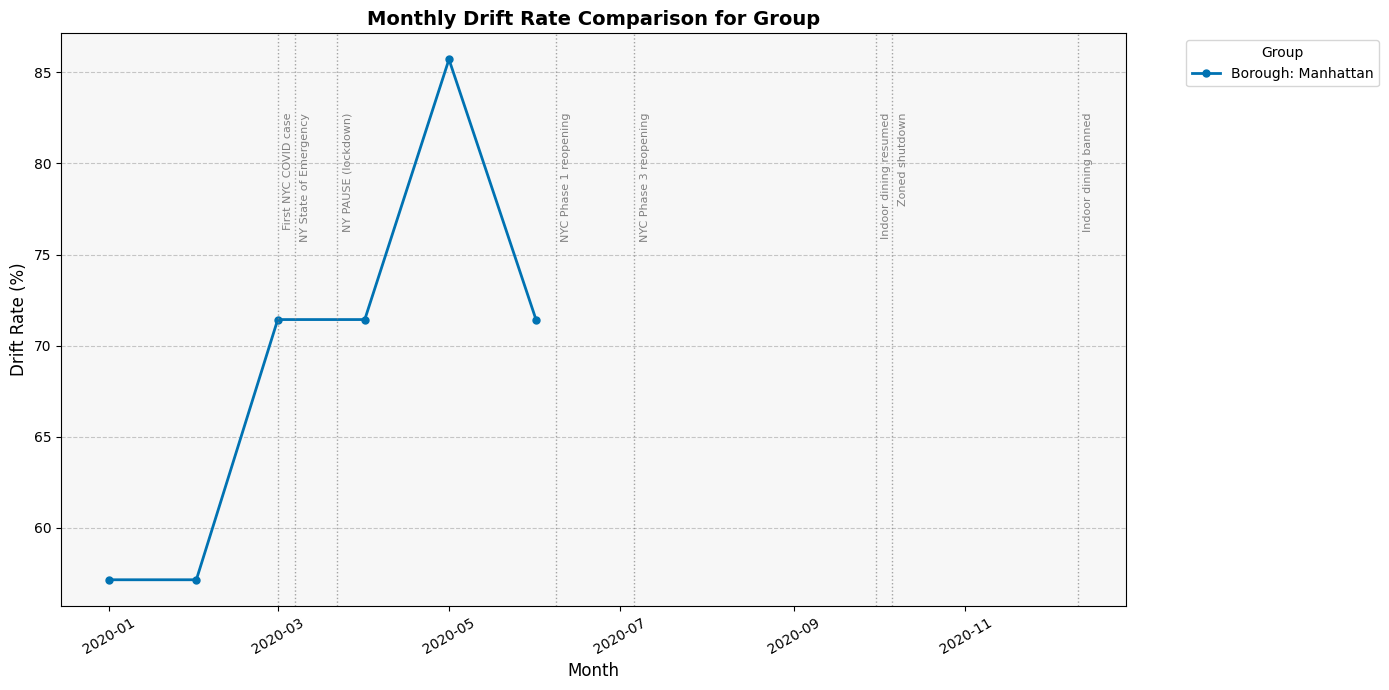

In [ ]:
# --- Plot for Borough: Manhattan ---
plot_drift_comparison(
    drift_detailed_df=drift_detailed,
    features_to_plot=example_features,
    group_column='group',
    group_labels=['Borough: Manhattan'],
    colors=borough_colors,
    covid_dates=COVID_DATES,
    save_path_prefix="monthly_comparison_borough_manhattan"
)

Saved: monthly_comparison_borough_queens_drift_comparison_group_Borough__Queens.png


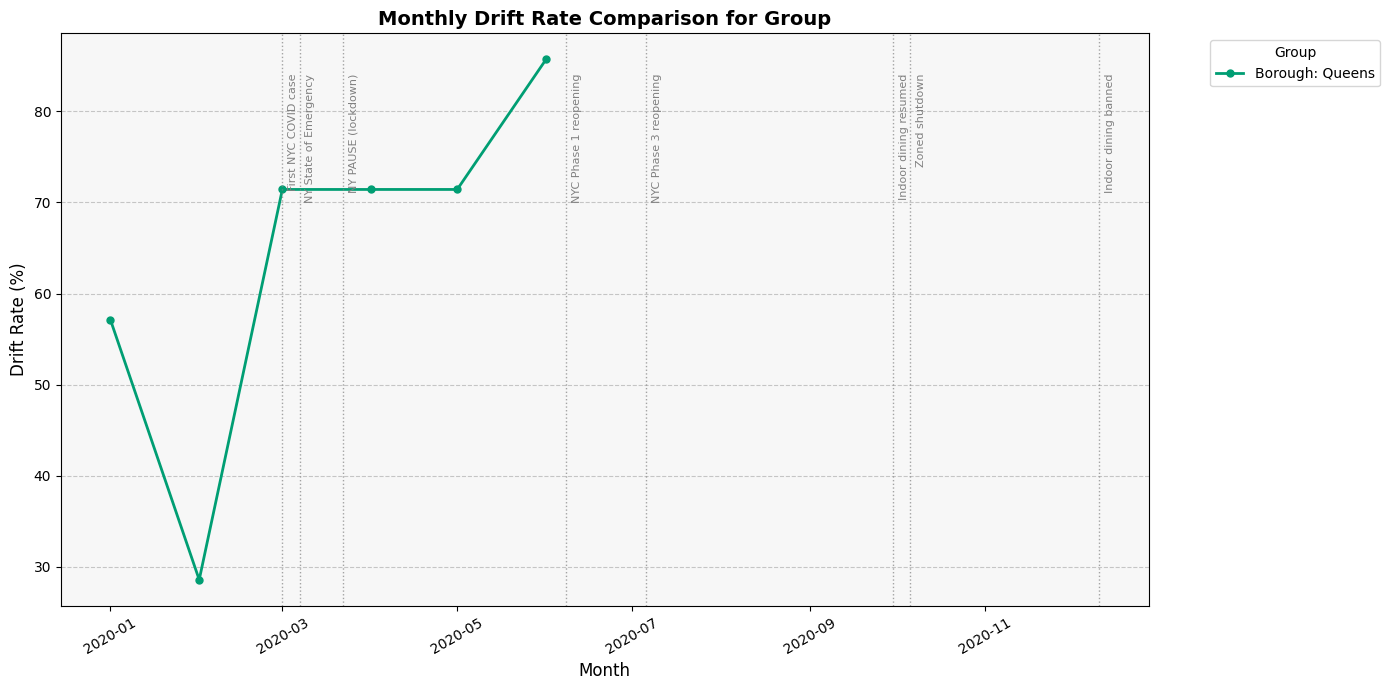

In [ ]:
# --- Plot for Borough: Queens ---
plot_drift_comparison(
    drift_detailed_df=drift_detailed,
    features_to_plot=example_features,
    group_column='group',
    group_labels=['Borough: Queens'],
    colors=borough_colors,
    covid_dates=COVID_DATES,
    save_path_prefix="monthly_comparison_borough_queens"
)

Saved: monthly_comparison_borough_brooklyn_drift_comparison_group_Borough__Brooklyn.png


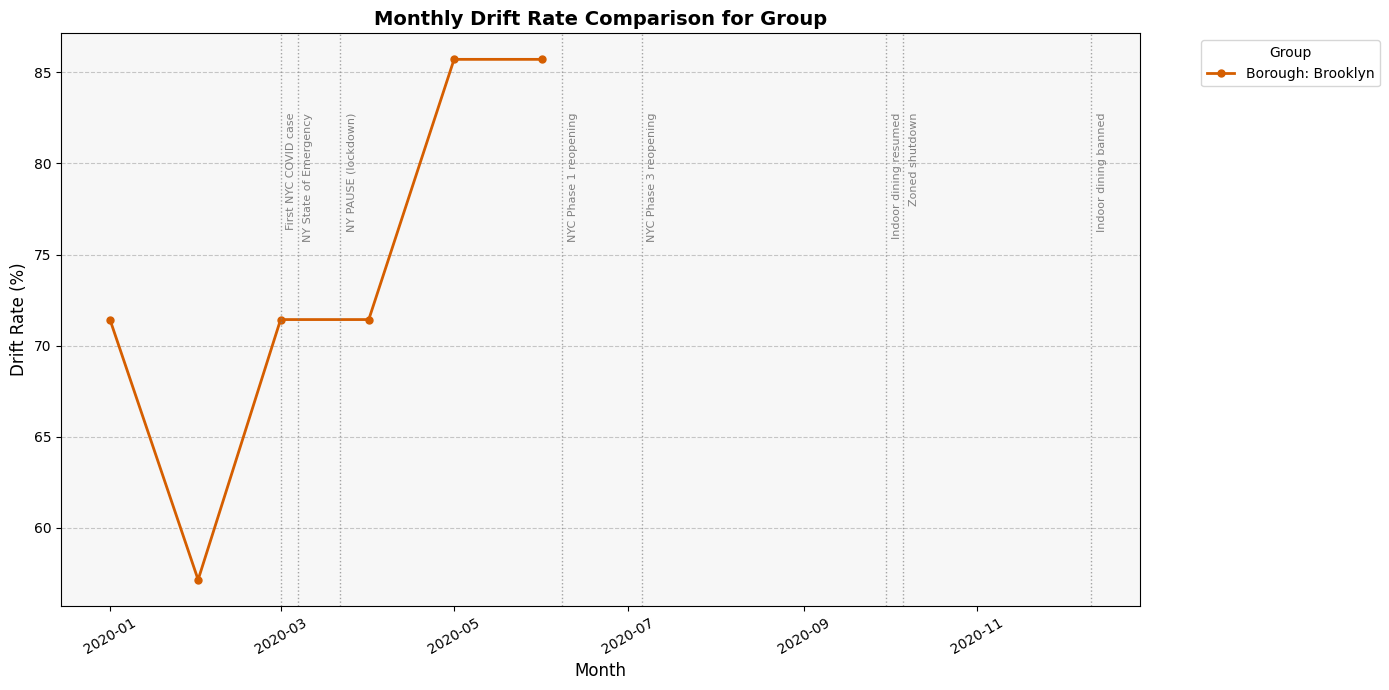

In [ ]:
# --- Plot for Borough: Brooklyn ---
plot_drift_comparison(
    drift_detailed_df=drift_detailed,
    features_to_plot=example_features,
    group_column='group',
    group_labels=['Borough: Brooklyn'],
    colors=borough_colors,
    covid_dates=COVID_DATES,
    save_path_prefix="monthly_comparison_borough_brooklyn"
)

Saved: monthly_comparison_sz_yellow_zone_drift_comparison_group_SZ__Yellow_Zone.png


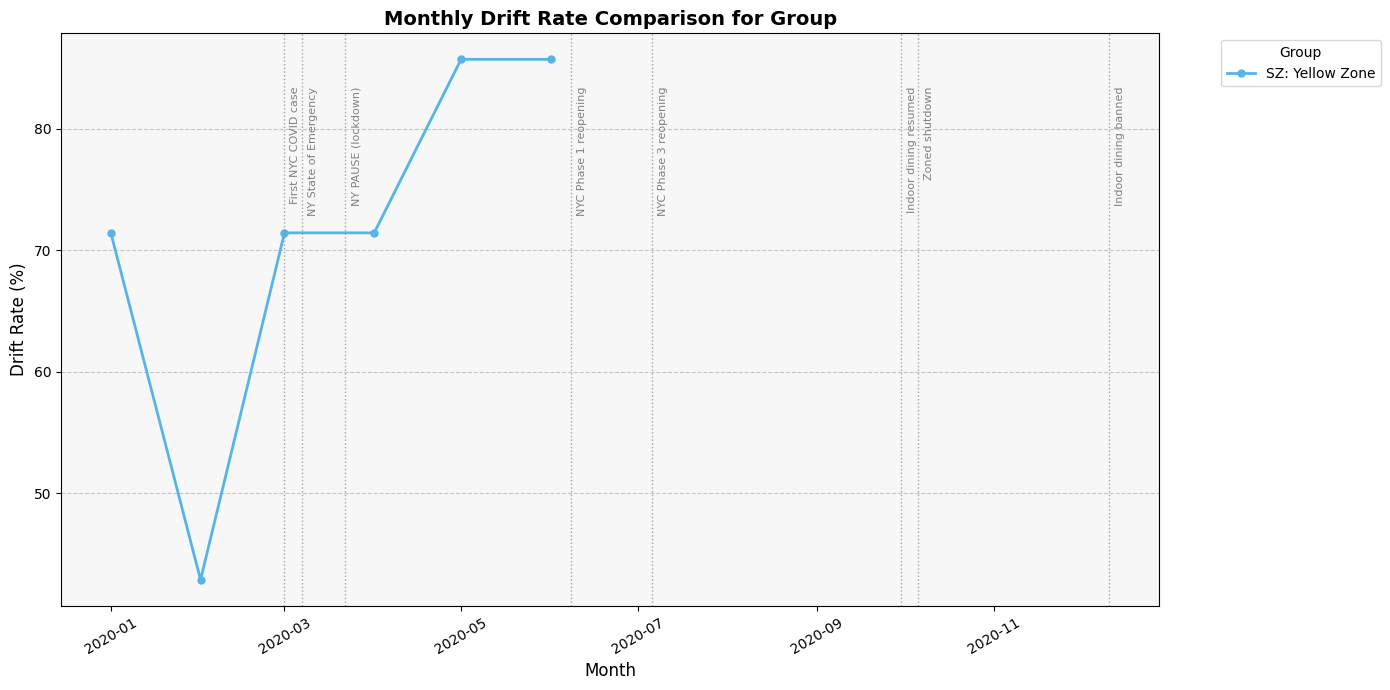

In [ ]:
# --- Plot for SZ: Yellow Zone ---
plot_drift_comparison(
    drift_detailed_df=drift_detailed,
    features_to_plot=example_features,
    group_column='group',
    group_labels=['SZ: Yellow Zone'],
    colors=service_zone_colors,
    covid_dates=COVID_DATES,
    save_path_prefix="monthly_comparison_sz_yellow_zone"
)

Saved: monthly_comparison_sz_boro_zone_drift_comparison_group_SZ__Boro_Zone.png


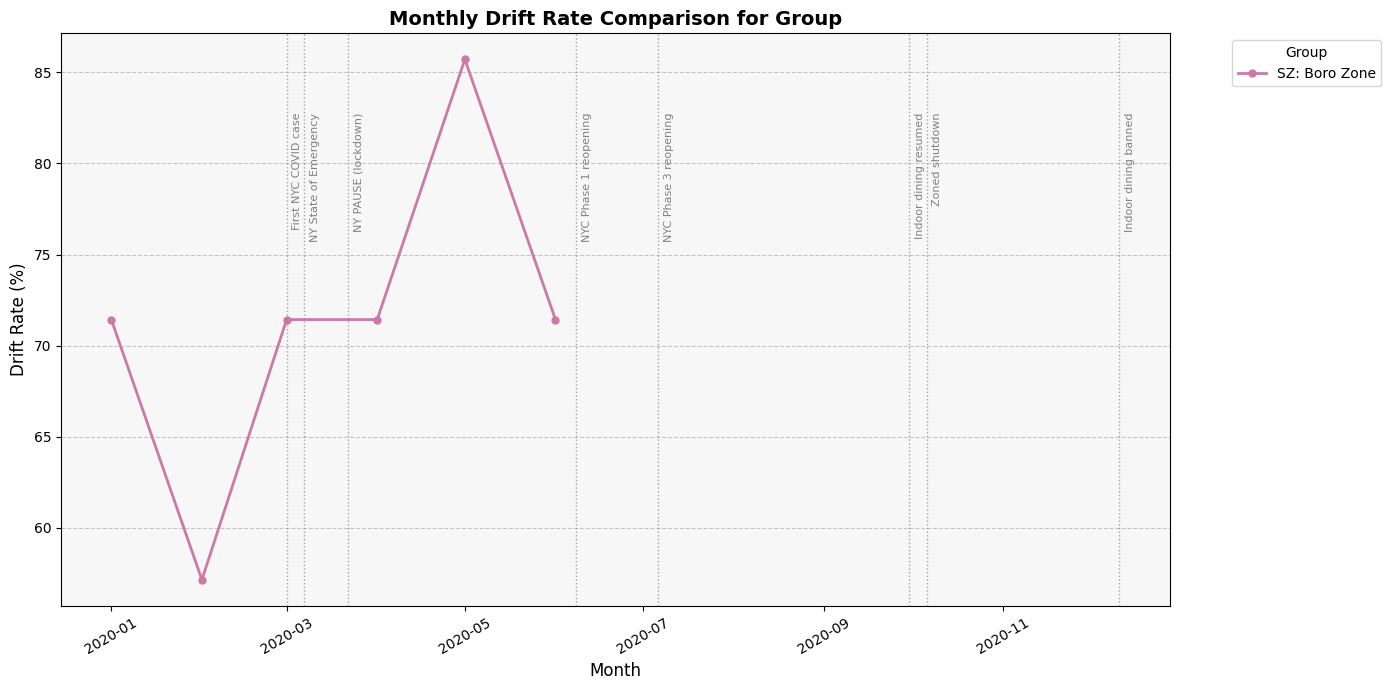

In [ ]:
# --- Plot for SZ: Boro Zone ---
plot_drift_comparison(
    drift_detailed_df=drift_detailed,
    features_to_plot=example_features,
    group_column='group',
    group_labels=['SZ: Boro Zone'],
    colors=service_zone_colors,
    covid_dates=COVID_DATES,
    save_path_prefix="monthly_comparison_sz_boro_zone"
)

Saved: monthly_comparison_sz_airports_drift_comparison_group_SZ__Airports.png


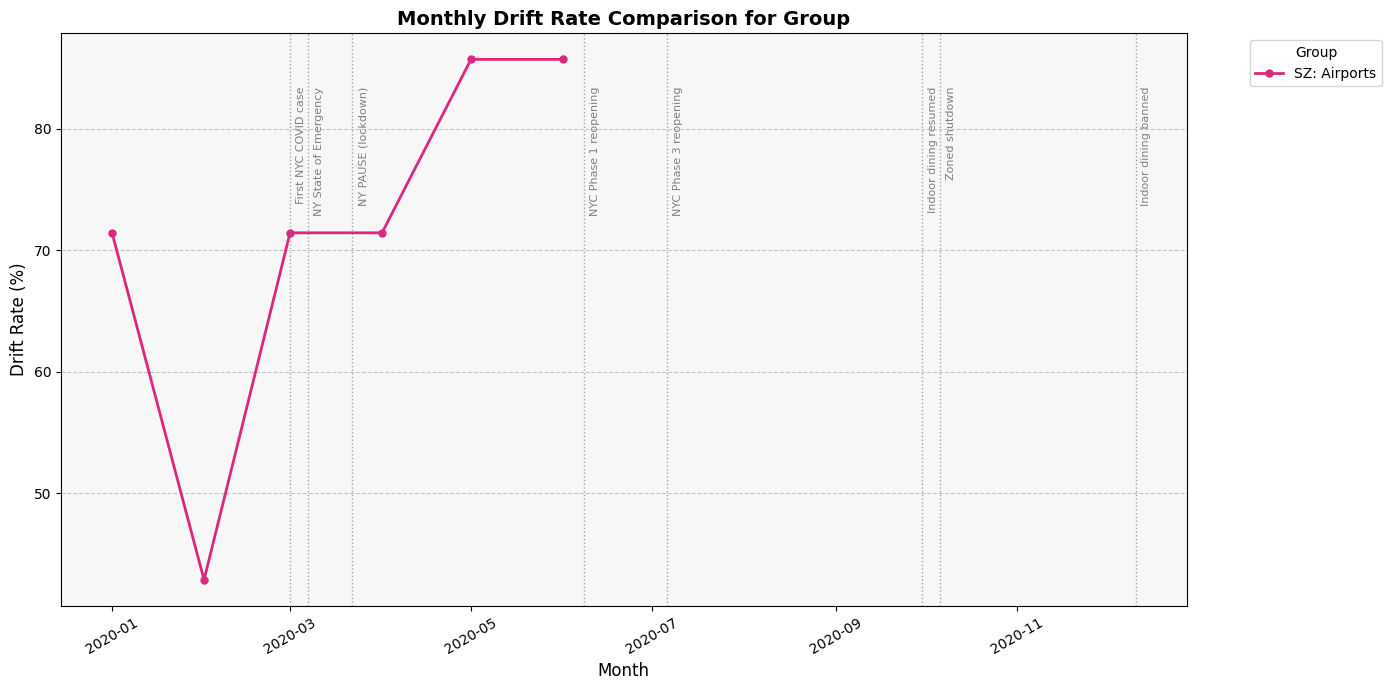

In [ ]:
# --- Plot for SZ: Airports ---
plot_drift_comparison(
    drift_detailed_df=drift_detailed,
    features_to_plot=example_features,
    group_column='group',
    group_labels=['SZ: Airports'],
    colors=service_zone_colors,
    covid_dates=COVID_DATES,
    save_path_prefix="monthly_comparison_sz_airports"
)

#### 4.5 Check sensitivity of metrics

Here we want to see which metrics are more sensitive than others if their performance withstand to literature claims.

In [ ]:
def classify_with_thresholds(row, thresholds):
    """
    Classify a data row into a drift category based on a voting consensus
    of threshold breaches across multiple metrics.
    """
    def level(val, metric):
        """Map raw metric value to a tier score: 0=Stable, 1=Moderate, 2=Significant."""
        if pd.isna(val):
            return 0

        t = thresholds[metric]
        if val >= t["significant"]:
            return 2
        elif val >= t["moderate"]:
            return 1
        return 0

    # Extract relevant metric scores present in the row
    metric_scores = {m: row[m] for m in thresholds.keys() if m in row.index}
    levels = [level(v, m) for m, v in metric_scores.items()]
    n = len(levels)

    # Aggregate votes for drift presence and intensity
    votes_drifted = sum(l >= 1 for l in levels)
    votes_significant = sum(l >= 2 for l in levels)

    # Dynamically determine voting consensus requirements based on metric count
    if n == 1:
        sig_thresh, mod_thresh = 1, 1
    elif n == 2:
        sig_thresh, mod_thresh = 1, 1
    else:
        # For 3+ metrics, require at least 2 metrics drifting, with at least 1 significant
        sig_thresh, mod_thresh = 1, 2

    # Apply voting logic to determine the consensus label
    if votes_drifted >= mod_thresh and votes_significant >= sig_thresh:
        return "SIGNIFICANT DRIFT"
    elif votes_drifted >= mod_thresh:
        return "MODERATE DRIFT"
    else:
        return "STABLE"


def sweep_sensitivity_by_metric(
    df,
    metric_cols,
    base_thresholds,
    scale_grid=(0.8, 0.9, 1.0, 1.1, 1.2),
    metric_families=None
):
    """
    Test systemic stability by scaling one metric's thresholds at a time
    across a grid and calculating the rate of output label flips.
    """
    if metric_families is None:
        metric_families = {m: m for m in metric_cols}

    df = df.copy()

    # Establish baseline classifications using unscaled thresholds
    base_labels = df.apply(lambda r: classify_with_thresholds(r, base_thresholds), axis=1)

    rows = []

    # Iteratively perturb thresholds for each individual metric
    for metric in metric_cols:
        family = metric_families.get(metric, metric)

        for mod_scale in scale_grid:
            for sig_scale in scale_grid:
                # Deep-ish copy of thresholds to isolate changes to current metric
                thresholds = {m: base_thresholds[m].copy() for m in metric_cols}

                # Apply scale factors to the target metric
                thresholds[metric]["moderate"] *= mod_scale
                thresholds[metric]["significant"] *= sig_scale

                # Evaluate classification stability under the perturbed rule
                labels = df.apply(lambda r: classify_with_thresholds(r, thresholds), axis=1)

                # Capture drift distribution shifts and label flip rates
                rows.append({
                    "metric": metric,
                    "metric_family": family,
                    "moderate_scale": mod_scale,
                    "significant_scale": sig_scale,
                    "label_change_rate": (labels != base_labels).mean(),
                    "significant_drift_rate": (labels == "SIGNIFICANT DRIFT").mean(),
                    "moderate_drift_rate": (labels == "MODERATE DRIFT").mean(),
                    "stable_rate": (labels == "STABLE").mean(),
                })

    return pd.DataFrame(rows)


def summarize_sensitivity(result_df):
    """
    Aggregate grid-sweep results to isolate high-variance, highly sensitive metrics.
    """
    return (
        result_df.groupby(["metric", "metric_family"], as_index=False)
        .agg(
            mean_label_change_rate=("label_change_rate", "mean"),
            max_label_change_rate=("label_change_rate", "max"),
            min_label_change_rate=("label_change_rate", "min"),
            mean_significant_rate=("significant_drift_rate", "mean"),
            mean_moderate_rate=("moderate_drift_rate", "mean"),
            mean_stable_rate=("stable_rate", "mean"),
        )
        # Order by highest impact on final drift classifications
        .sort_values("mean_label_change_rate", ascending=False)
        .reset_index(drop=True)
    )


# ── Execution Table Display ────────────────────────────────────────

metric_cols = ["psi", "js", "wass_norm", "median_shift", "l_inf", "prop_delta"]

metric_families = {
    "psi": "distribution",
    "js": "distribution",
    "wass_norm": "distribution",
    "median_shift": "shift",
    "l_inf": "shift",
    "prop_delta": "binary"
}

# Run the grid search sensitivity analysis
sensitivity_results = sweep_sensitivity_by_metric(
    drift_detailed,
    metric_cols=metric_cols,
    base_thresholds=DRIFT_THRESHOLDS,
    scale_grid=(0.8, 0.9, 1.0, 1.1, 1.2),
    metric_families=metric_families
)

# Compile raw aggregates
sensitivity_summary = summarize_sensitivity(sensitivity_results)



In [ ]:
display(sensitivity_summary)

,metric,metric_family,mean_label_change_rate,max_label_change_rate,min_label_change_rate,mean_significant_rate,mean_moderate_rate,mean_stable_rate
0,js,distribution,0.012531,0.026316,0.0,0.276692,0.039599,0.683709
1,wass_norm,distribution,0.005514,0.012531,0.0,0.275188,0.038095,0.686717
2,psi,distribution,0.000501,0.001253,0.0,0.273183,0.040602,0.686216
3,l_inf,shift,0.000000,0.000000,0.0,0.273183,0.040100,0.686717
4,prop_delta,binary,0.000000,0.000000,0.0,0.273183,0.040100,0.686717
5,median_shift,shift,0.000000,0.000000,0.0,0.273183,0.040100,0.686717


Jensen Shannon has the highest mean label change rate, making it more senstive to other metrics. This is consisntent with literature. PSI is also not as sensitive which is as expected.

#### 4.6 Trend of number of drifting features

In [ ]:
# ------------------------------------------------------------
# 1) Prepare the detailed drift table
# ------------------------------------------------------------
drift_df = drift_detailed.copy()

# Ensure month is a datetime month stamp
drift_df["month"] = pd.to_datetime(drift_df["month"]).dt.to_period("M").dt.to_timestamp()

# Mark whether each feature drifted
drift_df["drifted"] = drift_df["drift_label"].ne("STABLE")


# ------------------------------------------------------------
# 2) Monthly timeline summary
# ------------------------------------------------------------
timeline_counts = (
    drift_df.groupby("month", as_index=False)
    .agg(
        n_features=("feature", "count"),
        n_drifted=("drifted", "sum")
    )
)

timeline_counts["drift_rate"] = (
    timeline_counts["n_drifted"] / timeline_counts["n_features"]
)

timeline_counts = timeline_counts.sort_values("month").reset_index(drop=True)


# ------------------------------------------------------------
# 3) Monthly summary by feature type
# ------------------------------------------------------------
type_summary = (
    drift_df.groupby(["month", "feat_group"], as_index=False)
    .agg(
        n_features=("feature", "count"),
        n_drifted=("drifted", "sum")
    )
)

type_summary["drift_rate"] = (
    type_summary["n_drifted"] / type_summary["n_features"]
)

type_summary = type_summary.sort_values(["month", "feat_group"]).reset_index(drop=True)


# ------------------------------------------------------------
# 4) Optional wide table for easier reporting
# ------------------------------------------------------------
type_summary_wide = (
    type_summary.pivot(index="month", columns="feat_group", values="drift_rate")
    .reset_index()
)

# Save outputs
# timeline_counts.to_csv("timeline_counts.csv", index=False)
# type_summary.to_csv("type_summary_long.csv", index=False)
# type_summary_wide.to_csv("type_summary_wide.csv", index=False)

In [ ]:
type_summary_wide

feat_group,month,binary,cyclical,lagged,spatial,weather
0,2020-01-01,0.666667,0.333333,0.500000,0.095238,0.750000
1,2020-02-01,0.666667,0.333333,0.452381,0.095238,0.464286
2,2020-03-01,0.333333,0.333333,1.000000,0.095238,0.500000
3,2020-04-01,0.333333,0.333333,1.000000,0.095238,0.500000
4,2020-05-01,0.333333,0.333333,1.000000,0.095238,0.714286
5,2020-06-01,0.333333,0.333333,1.000000,0.095238,0.642857


Here we can see that for months March onwards, the lagged features seem to always have a drift rate of 100%. This means that all the features are drifting after covid, and are affected by the trip count.

### Step 5: Detect Concept Drifts

In [ ]:
# results = run_concept_drift_analysis(
#     monitoring_df     = monitoring_with_preds,
#     ref_df            = reference_data,
#     drift_detailed    = drift_detailed,
#     policy_dates      = COVID_DATES,
#     output_dir        = OUT_DIR,
#     exclude_groups    = {'EWR', 'Unknown'},
#     time_col          = 'pickup_hour_ts',
#     target_col        = 'trip_count',
#     residual_col      = 'residual',
#     group_col         = 'borough',
#     month_col         = 'month',
#     streams           = [('trip_count', 'Target'), ('residual', 'Residual')],
# )

In [ ]:
# ########## Stage 5. Concept Drift Analysis ##########

from pipeline_config import *

# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from river import drift


# ══════════════════════════════════════════════════════════════════════════════
# SECTION A: STREAM HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def make_weekly_stream(df, value_col, group_col='borough',
                       time_col='pickup_hour_ts', group_value=None):
    """
    Aggregate hourly data to weekly mean for change-point detection.
    group_value=None returns the overall (all-group) stream.
    """
    d = df.copy()
    if group_value is not None:
        d = d[d[group_col].astype(str) == str(group_value)]
    d['week'] = pd.to_datetime(d[time_col]).dt.to_period('W').dt.start_time
    weekly = (
        d.groupby('week')[value_col]
        .mean().reset_index().sort_values('week')
        .rename(columns={value_col: 'value'})
    )
    weekly[group_col] = group_value if group_value is not None else 'Overall'
    return weekly


def make_daily_stream(df, value_col, group_col='borough',
                      time_col='pickup_hour_ts', group_value=None):
    """
    Aggregate hourly data to daily mean.
    Used for ADWIN which needs more observations than weekly provides.
    """
    d = df.copy()
    if group_value is not None:
        d = d[d[group_col].astype(str) == str(group_value)]
    d['day'] = pd.to_datetime(d[time_col]).dt.floor('D')
    daily = (
        d.groupby('day')[value_col]
        .mean().reset_index().sort_values('day')
        .rename(columns={value_col: 'value'})
    )
    daily[group_col] = group_value if group_value is not None else 'Overall'
    daily = daily.rename(columns={'day': 'week'})  # keep col name consistent
    return daily


def make_hourly_zoomed_stream(df, value_col, group_col='borough',
                               time_col='pickup_hour_ts',
                               zoom_start='2020-03-01',
                               zoom_end='2020-04-30',
                               group_value=None):
    """
    Return hourly data zoomed to a specific date window.
    Used to run ADWIN at high resolution around the COVID onset period,
    giving ADWIN enough observations to detect abrupt within-window shifts.
    """
    d = df.copy()
    d[time_col] = pd.to_datetime(d[time_col])
    d = d[(d[time_col] >= zoom_start) & (d[time_col] <= zoom_end)]
    if group_value is not None:
        d = d[d[group_col].astype(str) == str(group_value)]
    hourly = (
        d.groupby(time_col)[value_col]
        .mean().reset_index().sort_values(time_col)
        .rename(columns={value_col: 'value', time_col: 'week'})
    )
    hourly[group_col] = group_value if group_value is not None else 'Overall'
    return hourly


# ══════════════════════════════════════════════════════════════════════════════
# SECTION B: DETECTOR
# ══════════════════════════════════════════════════════════════════════════════

def run_detectors(stream_df, stream_name, group_col='borough',
                  detector_params=None):
    """
    Run ADWIN and Page-Hinkley on a stream DataFrame.
    Detects downward shifts by negating the stream values.

    ADWIN: suited to gradual drift; needs sufficient observations (use daily
    or hourly for short monitoring windows — weekly is too sparse).
    Page-Hinkley: CUSUM-derived; detects abrupt monotonic shifts quickly.

    Parameters
    ----------
    stream_df       : DataFrame with columns ['week', 'value', group_col]
    stream_name     : label for this stream e.g. 'Target', 'Residual'
    detector_params : dict — override default detector configuration

    Returns DataFrame of detected change points.
    """
    if detector_params is None:
        detector_params = {
            'adwin_delta'      : 0.002,   # more sensitive than default 0.01
            'adwin_min_window' : 5,
            'ph_min_instances' : 5,
            'ph_delta'         : 0.005,
            'ph_threshold'     : 25,
            'ph_alpha'         : 0.9999,
        }

    adwin_inst = drift.ADWIN(
        delta=detector_params['adwin_delta'],
        min_window_length=detector_params['adwin_min_window'],
    )
    ph_inst = drift.PageHinkley(
        min_instances=detector_params['ph_min_instances'],
        delta=detector_params['ph_delta'],
        threshold=detector_params['ph_threshold'],
        alpha=detector_params['ph_alpha'],
    )

    change_points = []
    values = stream_df['value'].tolist()
    times  = stream_df['week'].tolist()
    group  = stream_df[group_col].iloc[0]

    for t, val in zip(times, values):
        # Negate to detect downward shifts
        adwin_inst.update(-val)
        if adwin_inst.drift_detected:
            change_points.append({
                'week'    : t,
                group_col : group,
                'stream'  : stream_name,
                'detector': 'ADWIN',
                'value'   : round(val, 3),
            })

        ph_inst.update(-val)
        if ph_inst.drift_detected:
            change_points.append({
                'week'    : t,
                group_col : group,
                'stream'  : stream_name,
                'detector': 'PageHinkley',
                'value'   : round(val, 3),
            })

    return pd.DataFrame(change_points)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION C: CONSISTENCY CHECKS
# ══════════════════════════════════════════════════════════════════════════════

def check_group_consistency(cp_df, groups, stream_name, detector,
                             group_col='borough'):
    """Exact-week consistency: count groups firing at the same week."""
    subset = cp_df[
        (cp_df['stream']   == stream_name) &
        (cp_df['detector'] == detector)    &
        (cp_df[group_col].isin(groups))
    ]
    if subset.empty:
        return pd.DataFrame()
    summary = (
        subset.groupby('week')
        .agg(
            groups_fired=(group_col, lambda x: ', '.join(sorted(x))),
            n_groups=(group_col, 'count'),
        )
        .reset_index().sort_values('week')
    )
    summary['consensus'] = summary['n_groups'] >= 2
    return summary


def check_group_consistency_window(cp_df, groups, stream_name, detector,
                                    group_col='borough', window_weeks=2,
                                    policy_dates=None):
    """Rolling-window consistency: flag weeks where 2+ groups fire within ±window."""
    subset = cp_df[
        (cp_df['stream']   == stream_name) &
        (cp_df['detector'] == detector)    &
        (cp_df[group_col].isin(groups))
    ].copy()
    if subset.empty:
        return pd.DataFrame()

    subset  = subset.sort_values('week')
    records = []
    for _, row in subset.iterrows():
        w_start = row['week'] - pd.Timedelta(weeks=window_weeks)
        w_end   = row['week'] + pd.Timedelta(weeks=window_weeks)
        nearby  = subset[
            (subset['week']    >= w_start) &
            (subset['week']    <= w_end)   &
            (subset[group_col] != row[group_col])
        ]
        if not nearby.empty:
            records.append({
                'anchor_group' : row[group_col],
                'anchor_week'  : row['week'],
                'nearby_groups': ', '.join(sorted(nearby[group_col].unique())),
                'nearby_weeks' : ', '.join(
                    nearby['week'].dt.strftime('%Y-%m-%d').unique()
                ),
                'n_groups'     : len(nearby[group_col].unique()) + 1,
                'stream'       : stream_name,
                'detector'     : detector,
            })
    if not records:
        return pd.DataFrame()

    result = (
        pd.DataFrame(records)
        .drop_duplicates(subset=['anchor_week', 'stream', 'detector'])
        .sort_values('anchor_week')
    )
    if policy_dates:
        result['nearest_policy'] = result['anchor_week'].apply(
            lambda w: min(policy_dates.keys(),
                          key=lambda d: abs(pd.to_datetime(d) - w))
        )
        result['policy_label']    = result['nearest_policy'].map(policy_dates)
        result['days_from_policy'] = result.apply(
            lambda r: (r['anchor_week'] - pd.to_datetime(r['nearest_policy'])).days,
            axis=1
        )
    return result


# ══════════════════════════════════════════════════════════════════════════════
# SECTION D: MAIN ANALYSIS WRAPPER
# Returns results only — no plotting
# ══════════════════════════════════════════════════════════════════════════════

def run_concept_drift_analysis(
    monitoring_df,
    ref_df=None,
    drift_detailed=None,
    policy_dates=None,
    exclude_groups=None,
    detector_params=None,
    time_col='pickup_hour_ts',
    target_col='trip_count',
    residual_col='residual',
    group_col='borough',
    month_col='file_month',
    streams=None,
    granularity='weekly',       # 'weekly' or 'daily' — governs stream aggregation
    zoom_start=None,            # if set, zooms to hourly stream for ADWIN analysis
    zoom_end=None,
):
    """
    Run concept drift detection on monitoring data.
    Plotting is fully separated — use plot_concept_drift() for visualisation.

    Parameters
    ----------
    granularity : 'weekly' or 'daily'
        Weekly is standard; daily gives ADWIN more observations to work with.
        If zoom_start/zoom_end are set, runs an additional hourly zoomed
        ADWIN analysis on the specified date window regardless of granularity.

    Returns dict with keys:
        change_points, consistency_exact, consistency_window,
        weekly_stream, daily_stream (if granularity='daily'),
        zoomed_stream (if zoom window provided)
    """
    if exclude_groups is None:
        exclude_groups = {'EWR', 'Unknown', 'NaN', ''}
    if policy_dates is None:
        policy_dates = {}
    if streams is None:
        if residual_col and residual_col in monitoring_df.columns:
            streams = [(target_col, 'Target'), (residual_col, 'Residual')]
        else:
            streams = [(target_col, 'Target')]

    df = monitoring_df.copy()
    df[time_col] = pd.to_datetime(df[time_col])

    print(f"{'='*70}")
    print(f"  CONCEPT DRIFT ANALYSIS")
    print(f"  Granularity : {granularity}")
    print(f"  Data range  : {df[time_col].min()} → {df[time_col].max()}")
    print(f"  Rows        : {len(df):,} | Groups: {df[group_col].nunique()}")
    print(f"  Streams     : {', '.join([s[1] for s in streams])}")
    if zoom_start:
        print(f"  Zoomed ADWIN: {zoom_start} → {zoom_end} (hourly)")
    print(f"{'='*70}")

    groups = [g for g in df[group_col].astype(str).unique()
              if g not in exclude_groups]

    # ── Choose stream builder ─────────────────────────────────────────────────
    build_stream = make_daily_stream if granularity == 'daily' else make_weekly_stream

    all_cp = []
    stream_data = {}

    print("\n── Running detectors ──")
    for stream_col, stream_name in streams:
        if stream_col not in df.columns:
            print(f"  Skipping {stream_name} — '{stream_col}' not found")
            continue
        print(f"\n  Stream: {stream_name} ({granularity})")

        # Overall
        s = build_stream(df, stream_col, group_col, time_col)
        stream_data[stream_name] = s
        cp = run_detectors(s, stream_name, group_col, detector_params)
        all_cp.append(cp)
        print(f"    Overall      — {len(cp)} change points")

        # Per group
        for g in groups:
            s = build_stream(df, stream_col, group_col, time_col, group_value=g)
            cp = run_detectors(s, stream_name, group_col, detector_params)
            all_cp.append(cp)
            print(f"    {g:<15} — {len(cp)} change points")

    # ── Optional: zoomed hourly ADWIN around COVID window ─────────────────────
    zoomed_cp  = pd.DataFrame()
    zoomed_stream = {}
    if zoom_start and zoom_end:
        print(f"\n── Zoomed hourly ADWIN: {zoom_start} → {zoom_end} ──")
        # More sensitive ADWIN params for hourly resolution
        zoomed_params = {
            'adwin_delta'      : 0.002,
            'adwin_min_window' : 24,   # 1 full day of hourly observations
            'ph_min_instances' : 24,
            'ph_delta'         : 0.005,
            'ph_threshold'     : 15,   # lower threshold — shorter window
            'ph_alpha'         : 0.9999,
        }
        zoom_cp_all = []
        for stream_col, stream_name in streams:
            if stream_col not in df.columns:
                continue
            label = f"{stream_name}_zoomed"
            s = make_hourly_zoomed_stream(
                df, stream_col, group_col, time_col,
                zoom_start=zoom_start, zoom_end=zoom_end
            )
            zoomed_stream[stream_name] = s
            cp = run_detectors(s, label, group_col, zoomed_params)
            zoom_cp_all.append(cp)
            print(f"  Overall hourly {stream_name} — {len(cp)} change points")

            for g in groups:
                s = make_hourly_zoomed_stream(
                    df, stream_col, group_col, time_col,
                    zoom_start=zoom_start, zoom_end=zoom_end,
                    group_value=g
                )
                cp = run_detectors(s, label, group_col, zoomed_params)
                zoom_cp_all.append(cp)
                print(f"  {g:<15} hourly {stream_name} — {len(cp)} change points")

        if zoom_cp_all:
            zoomed_cp = pd.concat(zoom_cp_all, ignore_index=True)
            zoomed_cp['week'] = pd.to_datetime(zoomed_cp['week'])

    # ── Combine all change points ─────────────────────────────────────────────
    if not all_cp or all(len(c) == 0 for c in all_cp):
        print("\n  No change points detected")
        return {
            'change_points'     : pd.DataFrame(),
            'consistency_exact' : pd.DataFrame(),
            'consistency_window': pd.DataFrame(),
            'stream_data'       : stream_data,
            'zoomed_cp'         : zoomed_cp,
            'zoomed_stream'     : zoomed_stream,
        }

    cp_df = pd.concat(all_cp, ignore_index=True)
    cp_df['week'] = pd.to_datetime(cp_df['week'])
    print(f"\n  Total change points: {len(cp_df)}")

    # ── Group consistency ─────────────────────────────────────────────────────
    stream_labels = [s[1] for s in streams]
    print("\n── Group consistency (exact week) ──")
    consistency_exact = []
    for sn, det in [(s, d) for s in stream_labels
                    for d in ['ADWIN', 'PageHinkley']]:
        cons = check_group_consistency(cp_df, groups, sn, det, group_col)
        if cons.empty:
            print(f"  {sn} | {det} — no change points")
            continue
        agreed = cons[cons['consensus']]
        print(f"  {sn} | {det} — {len(agreed)} weeks with 2+ group agreement")
        if not agreed.empty:
            consistency_exact.append(agreed)

    print("\n── Group consistency (±2 week window) ──")
    consistency_window = []
    for sn, det in [(s, d) for s in stream_labels
                    for d in ['ADWIN', 'PageHinkley']]:
        cons = check_group_consistency_window(
            cp_df, groups, sn, det, group_col,
            window_weeks=2, policy_dates=policy_dates
        )
        if cons.empty:
            print(f"  {sn} | {det} — no agreement within window")
            continue
        print(f"  {sn} | {det} — {len(cons)} cluster(s) with 2+ group agreement")
        consistency_window.append(cons)

    print("\n── All change points ──")
    print(cp_df.sort_values(['stream', group_col, 'week'])
          [['stream', 'detector', group_col, 'week', 'value']]
          .to_string(index=False))

    return {
        'change_points'     : cp_df,
        'consistency_exact' : pd.concat(consistency_exact)
                              if consistency_exact else pd.DataFrame(),
        'consistency_window': pd.concat(consistency_window)
                              if consistency_window else pd.DataFrame(),
        'stream_data'       : stream_data,
        'zoomed_cp'         : zoomed_cp,
        'zoomed_stream'     : zoomed_stream,
    }




#### Plot and generate concept drift findings

In [ ]:
CB = {
    'target'  : '#0072B2',
    'residual': '#009E73',
    'ph'      : '#D55E00',
    'adwin'   : '#E69F00',
    'policy'  : '#555555',
    'covid'   : 'black',
}


def _apply_base_style(ax):
    ax.set_facecolor('#f7f7f7')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
    ax.tick_params(colors='#333333', labelsize=11)
    ax.yaxis.label.set_color('#333333')
    ax.yaxis.label.set_size(12)
    ax.grid(axis='y', color='#dddddd', linewidth=0.6)


def _add_policy_lines(ax, policy_dates, plot_end=None):
    """Add policy date vertical lines, optionally truncated at plot_end."""
    for dt, label in policy_dates.items():
        if plot_end and pd.to_datetime(dt) > pd.to_datetime(plot_end):
            continue
        ax.axvline(pd.to_datetime(dt), color=CB['policy'],
                   linewidth=1.2, linestyle=':', alpha=0.9, zorder=1)


def _add_policy_labels(ax, policy_dates, label_y, plot_end=None):
    for dt, label in policy_dates.items():
        if plot_end and pd.to_datetime(dt) > pd.to_datetime(plot_end):
            continue
        short = label.replace('NYC ', '').replace('NY ', '')
        ax.text(pd.to_datetime(dt), label_y, short,
                rotation=90, fontsize=8.5, color='#333333',
                va='top', ha='right',
                bbox=dict(boxstyle='round,pad=0.1',
                          facecolor='white', alpha=0.6, edgecolor='none'))


def _add_change_point_lines(ax, cp_df, stream_name, group_col,
                              group_filter=None):
    """Add PH and ADWIN vertical lines for a given stream and optional group."""
    sub = cp_df[cp_df['stream'] == stream_name]
    if group_filter is not None:
        sub = sub[sub[group_col] == group_filter]
    ph    = sub[sub['detector'] == 'PageHinkley']
    adwin = sub[sub['detector'] == 'ADWIN']
    for _, row in ph.iterrows():
        ax.axvline(row['week'], color=CB['ph'], linewidth=2.5,
                   linestyle='--', zorder=3, alpha=0.95)
    for _, row in adwin.iterrows():
        ax.axvline(row['week'], color=CB['adwin'], linewidth=2.5,
                   linestyle='-.', zorder=3, alpha=0.95)


def plot_concept_drift(
    results,
    group_col='borough',
    boroughs=None,
    policy_dates=None,
    plot_end='2020-07-01',       # truncate x-axis here — no indoor dining etc.
    save_dir=None,
    title_suffix='Overall',
):
    """
    Plot concept drift detection results.
    Fully separated from the analysis wrapper — call independently.

    Parameters
    ----------
    results      : dict returned by run_concept_drift_analysis()
    boroughs     : list of boroughs to plot; None = Overall only
    policy_dates : dict {date_str: label} — truncated at plot_end automatically
    plot_end     : str date — x-axis upper limit (default '2020-07-01')
    save_dir     : Path — where to save the output PNG
    title_suffix : str — appended to plot title e.g. 'Manhattan', 'Overall'
    """
    if policy_dates is None:
        policy_dates = {}

    cp_df       = results['change_points']
    stream_data = results['stream_data']
    plot_end_dt = pd.to_datetime(plot_end)

    # Determine which streams are available
    has_residual = 'Residual' in stream_data
    num_rows     = 2 if has_residual else 1

    fig, axes = plt.subplots(num_rows, 1, figsize=(16, 6 * num_rows), sharex=True)
    if num_rows == 1:
        axes = [axes]
    fig.patch.set_facecolor('white')

    for ax in axes:
        _apply_base_style(ax)
        _add_policy_lines(ax, policy_dates, plot_end=plot_end)

    # Determine group filter for change point lines
    group_filter = boroughs[0] if boroughs and len(boroughs) == 1 else None

    # ── Panel A: Target ───────────────────────────────────────────────────────
    ax   = axes[0]
    s    = stream_data.get('Target', pd.DataFrame())
    if not s.empty:
        s = s[s['week'] <= plot_end_dt]
        ax.plot(s['week'], s['value'],
                color=CB['target'], linewidth=2.5,
                label='Avg target', zorder=4)
        ax.fill_between(s['week'], s['value'],
                        alpha=0.15, color=CB['target'])

    _add_change_point_lines(ax, cp_df, 'Target', group_col, group_filter)
    _add_policy_labels(ax, policy_dates,
                       label_y=s['value'].max() * 0.92 if not s.empty else 1,
                       plot_end=plot_end)
    ax.set_ylabel('Avg target / period', fontsize=12)
    ax.set_title(f'Target Drift Detection — {title_suffix}',
                 fontsize=13, pad=10, color='#333333', fontweight='bold')
    ax.set_xlim(right=plot_end_dt)

    # ── Panel B: Residual ─────────────────────────────────────────────────────
    if has_residual:
        ax = axes[1]
        s  = stream_data.get('Residual', pd.DataFrame())
        if not s.empty:
            s = s[s['week'] <= plot_end_dt]
            ax.plot(s['week'], s['value'],
                    color=CB['residual'], linewidth=2.5,
                    label='Avg residual', zorder=4)
            ax.fill_between(s['week'], s['value'],
                            alpha=0.15, color=CB['residual'])
        ax.axhline(0, color='#333333', linewidth=1.0, linestyle='-', alpha=0.6)
        _add_change_point_lines(ax, cp_df, 'Residual', group_col, group_filter)
        ax.set_ylabel('Avg residual (actual − predicted)', fontsize=12)
        ax.set_title(f'Concept Drift — Residual Stream — {title_suffix}',
                     fontsize=13, pad=10, color='#333333', fontweight='bold')
        ax.tick_params(axis='x', rotation=30, labelsize=11)
        ax.set_xlim(right=plot_end_dt)

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_elements = [
        mpatches.Patch(color=CB['target'],   label='Avg target'),
        mpatches.Patch(color=CB['residual'], label='Avg residual'),
        plt.Line2D([0], [0], color=CB['ph'],     linewidth=2.5,
                   linestyle='--', label='PageHinkley'),
        plt.Line2D([0], [0], color=CB['adwin'],  linewidth=2.5,
                   linestyle='-.', label='ADWIN'),
        plt.Line2D([0], [0], color=CB['policy'], linewidth=1.5,
                   linestyle=':', label='Policy date'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=5,
               fontsize=10, framealpha=0.95,
               bbox_to_anchor=(0.5, -0.03 if num_rows == 1 else -0.04))
    plt.suptitle(f'Concept Drift Detection — {title_suffix}',
                 fontsize=14, fontweight='bold', y=1.02, color='#333333')
    plt.tight_layout(rect=[0, 0.04, 1, 1])

    if save_dir:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        fname = f"concept_drift_{title_suffix.lower().replace(' ', '_')}.png"
        plt.savefig(save_dir / fname, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"  Saved → {save_dir / fname}")
    plt.show()


def plot_zoomed_adwin(
    results,
    group_col='borough',
    policy_dates=None,
    zoom_start='2020-03-01',
    zoom_end='2020-04-30',
    save_dir=None,
):
    """
    Plot zoomed hourly ADWIN results around the COVID onset window.
    Shows daily granularity during the most critical drift period so
    ADWIN signals are visible at the resolution they were detected.

    Parameters
    ----------
    results    : dict returned by run_concept_drift_analysis()
    zoom_start : str — start of the zoomed window
    zoom_end   : str — end of the zoomed window
    """
    if policy_dates is None:
        policy_dates = {}

    zoomed_stream = results.get('zoomed_stream', {})
    zoomed_cp     = results.get('zoomed_cp', pd.DataFrame())

    if not zoomed_stream:
        print("  No zoomed stream data — re-run with zoom_start/zoom_end set")
        return

    streams_available = list(zoomed_stream.keys())
    num_rows = len(streams_available)

    fig, axes = plt.subplots(num_rows, 1,
                             figsize=(16, 5 * num_rows), sharex=True)
    if num_rows == 1:
        axes = [axes]
    fig.patch.set_facecolor('white')

    zoom_start_dt = pd.to_datetime(zoom_start)
    zoom_end_dt   = pd.to_datetime(zoom_end)

    for ax, stream_name in zip(axes, streams_available):
        _apply_base_style(ax)
        _add_policy_lines(ax, policy_dates, plot_end=zoom_end)

        s = zoomed_stream[stream_name]
        if not s.empty:
            color = CB['target'] if stream_name == 'Target' else CB['residual']
            ax.plot(s['week'], s['value'],
                    color=color, linewidth=2.0, label=f'Hourly {stream_name}',
                    zorder=4)
            ax.fill_between(s['week'], s['value'], alpha=0.12, color=color)

        # Draw ADWIN lines ONLY
        if not zoomed_cp.empty:
            label_zoomed = f"{stream_name}_zoomed"
            adwin_subset = zoomed_cp[
                (zoomed_cp['stream'] == label_zoomed) &
                (zoomed_cp['detector'] == 'ADWIN')
            ]
            for _, row in adwin_subset.iterrows():
                ax.axvline(row['week'], color=CB['adwin'], linewidth=2.5,
                           linestyle='-.', zorder=3, alpha=0.95)

        _add_policy_labels(ax, policy_dates,
                           label_y=s['value'].max() * 0.92 if not s.empty else 1,
                           plot_end=zoom_end)
        ax.set_ylabel(f'Hourly {stream_name}', fontsize=12)
        ax.set_title(f'Zoomed ADWIN — {stream_name} Stream (Hourly, {zoom_start} to {zoom_end})',
                     fontsize=12, pad=8, color='#333333', fontweight='bold')
        ax.set_xlim(zoom_start_dt, zoom_end_dt)

    axes[-1].tick_params(axis='x', rotation=30, labelsize=11)

    # Cleaned legend (Page-Hinkley removed)
    legend_elements = [
        plt.Line2D([0], [0], color=CB['adwin'],  linewidth=2.5,
                   linestyle='-.', label='ADWIN'),
        plt.Line2D([0], [0], color=CB['policy'], linewidth=1.5,
                   linestyle=':', label='Policy date'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2,
               fontsize=10, framealpha=0.95, bbox_to_anchor=(0.5, -0.04))
    plt.suptitle(f'Zoomed Hourly Drift Detection — COVID Onset Window',
                 fontsize=14, fontweight='bold', y=1.02, color='#333333')
    plt.tight_layout(rect=[0, 0.04, 1, 1])

    if save_dir:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_dir / 'concept_drift_zoomed_adwin.png',
                    dpi=150, bbox_inches='tight', facecolor='white')
        print(f"  Saved → {save_dir / 'concept_drift_zoomed_adwin.png'}")
    plt.show()


  CONCEPT DRIFT ANALYSIS
  Granularity : weekly
  Data range  : 2020-01-01 00:00:00 → 2020-06-30 23:00:00
  Rows        : 860,496 | Groups: 3
  Streams     : Target, Residual
  Zoomed ADWIN: 2020-03-01 → 2020-04-30 (hourly)

── Running detectors ──

  Stream: Target (weekly)
    Overall      — 1 change points
    Queens          — 1 change points
    Manhattan       — 2 change points
    Brooklyn        — 0 change points

  Stream: Residual (weekly)
    Overall      — 0 change points
    Queens          — 0 change points
    Manhattan       — 1 change points
    Brooklyn        — 0 change points

── Zoomed hourly ADWIN: 2020-03-01 → 2020-04-30 ──
  Overall hourly Target — 44 change points
  Queens          hourly Target — 22 change points
  Manhattan       hourly Target — 63 change points
  Brooklyn        hourly Target — 7 change points
  Overall hourly Residual — 31 change points
  Queens          hourly Residual — 9 change points
  Manhattan       hourly Residual — 41 change points


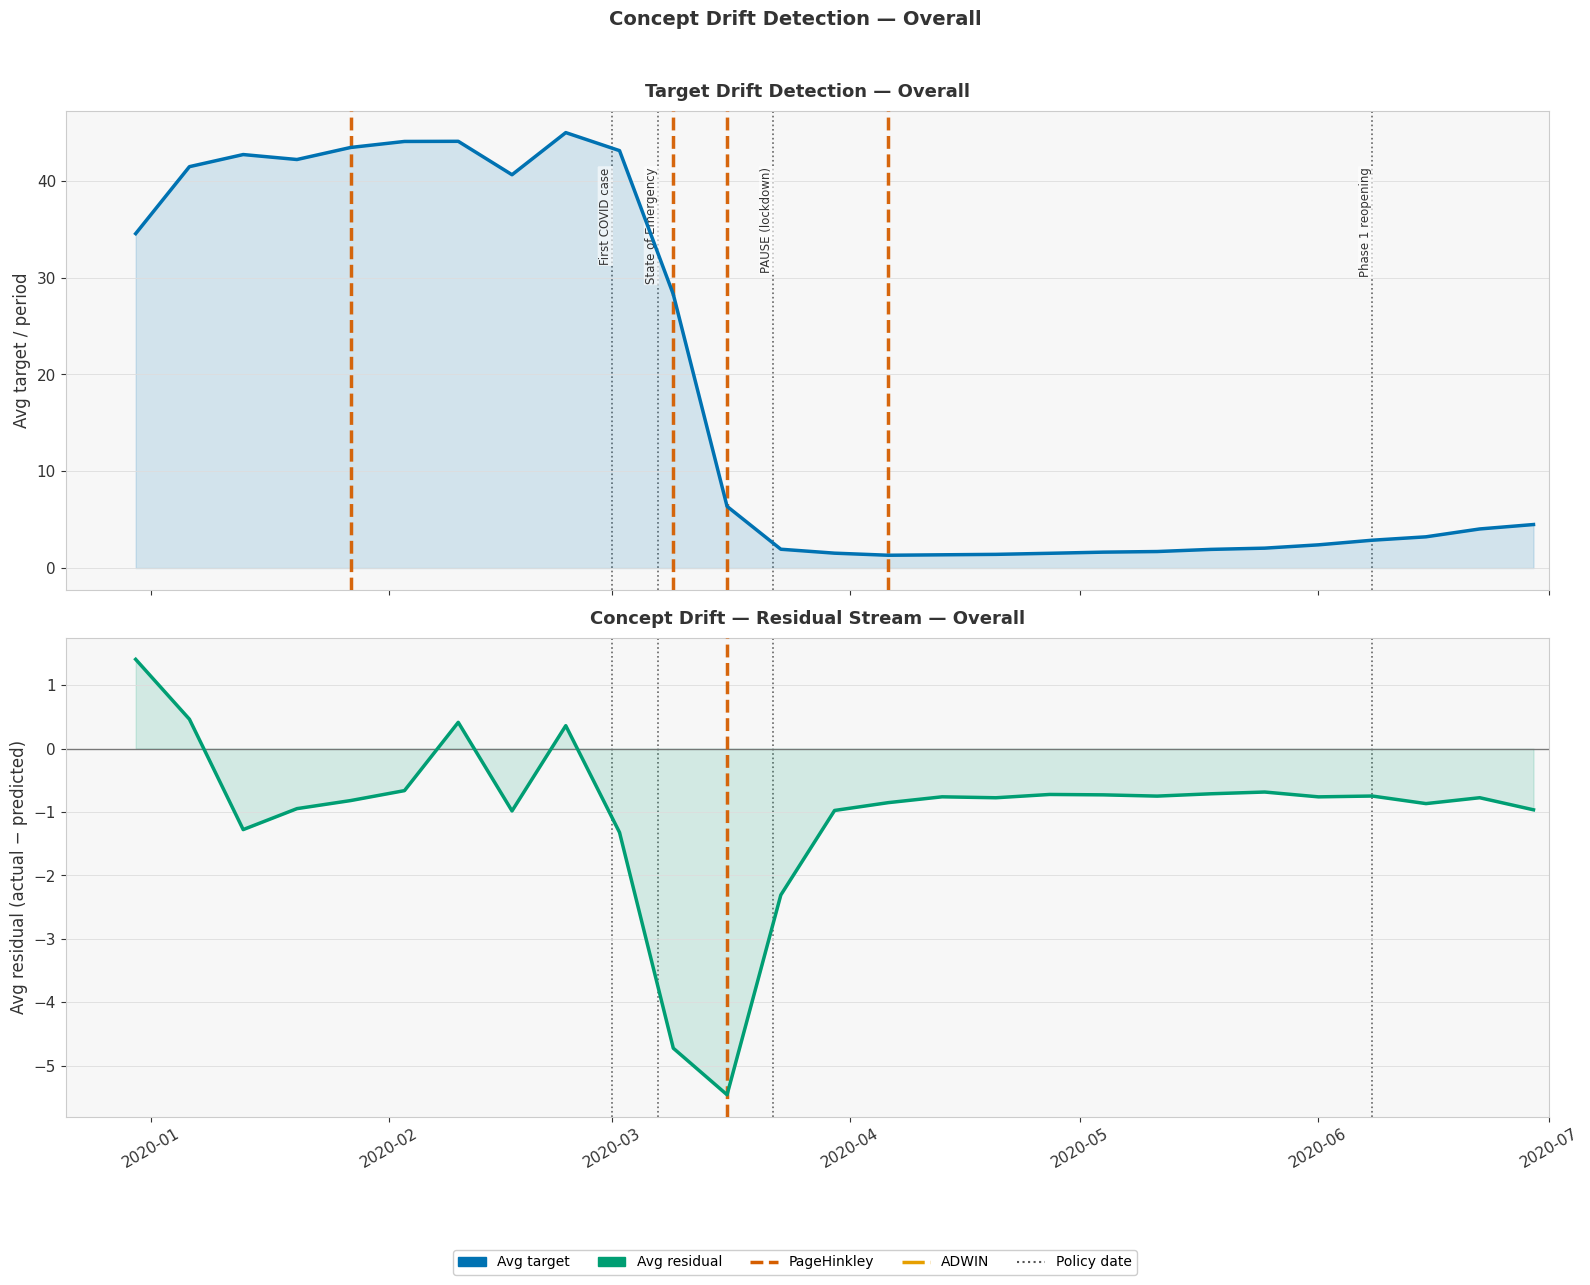

  Saved → /content/drive/MyDrive/ODATA57078/eda_outputs/concept_drift_manhattan.png


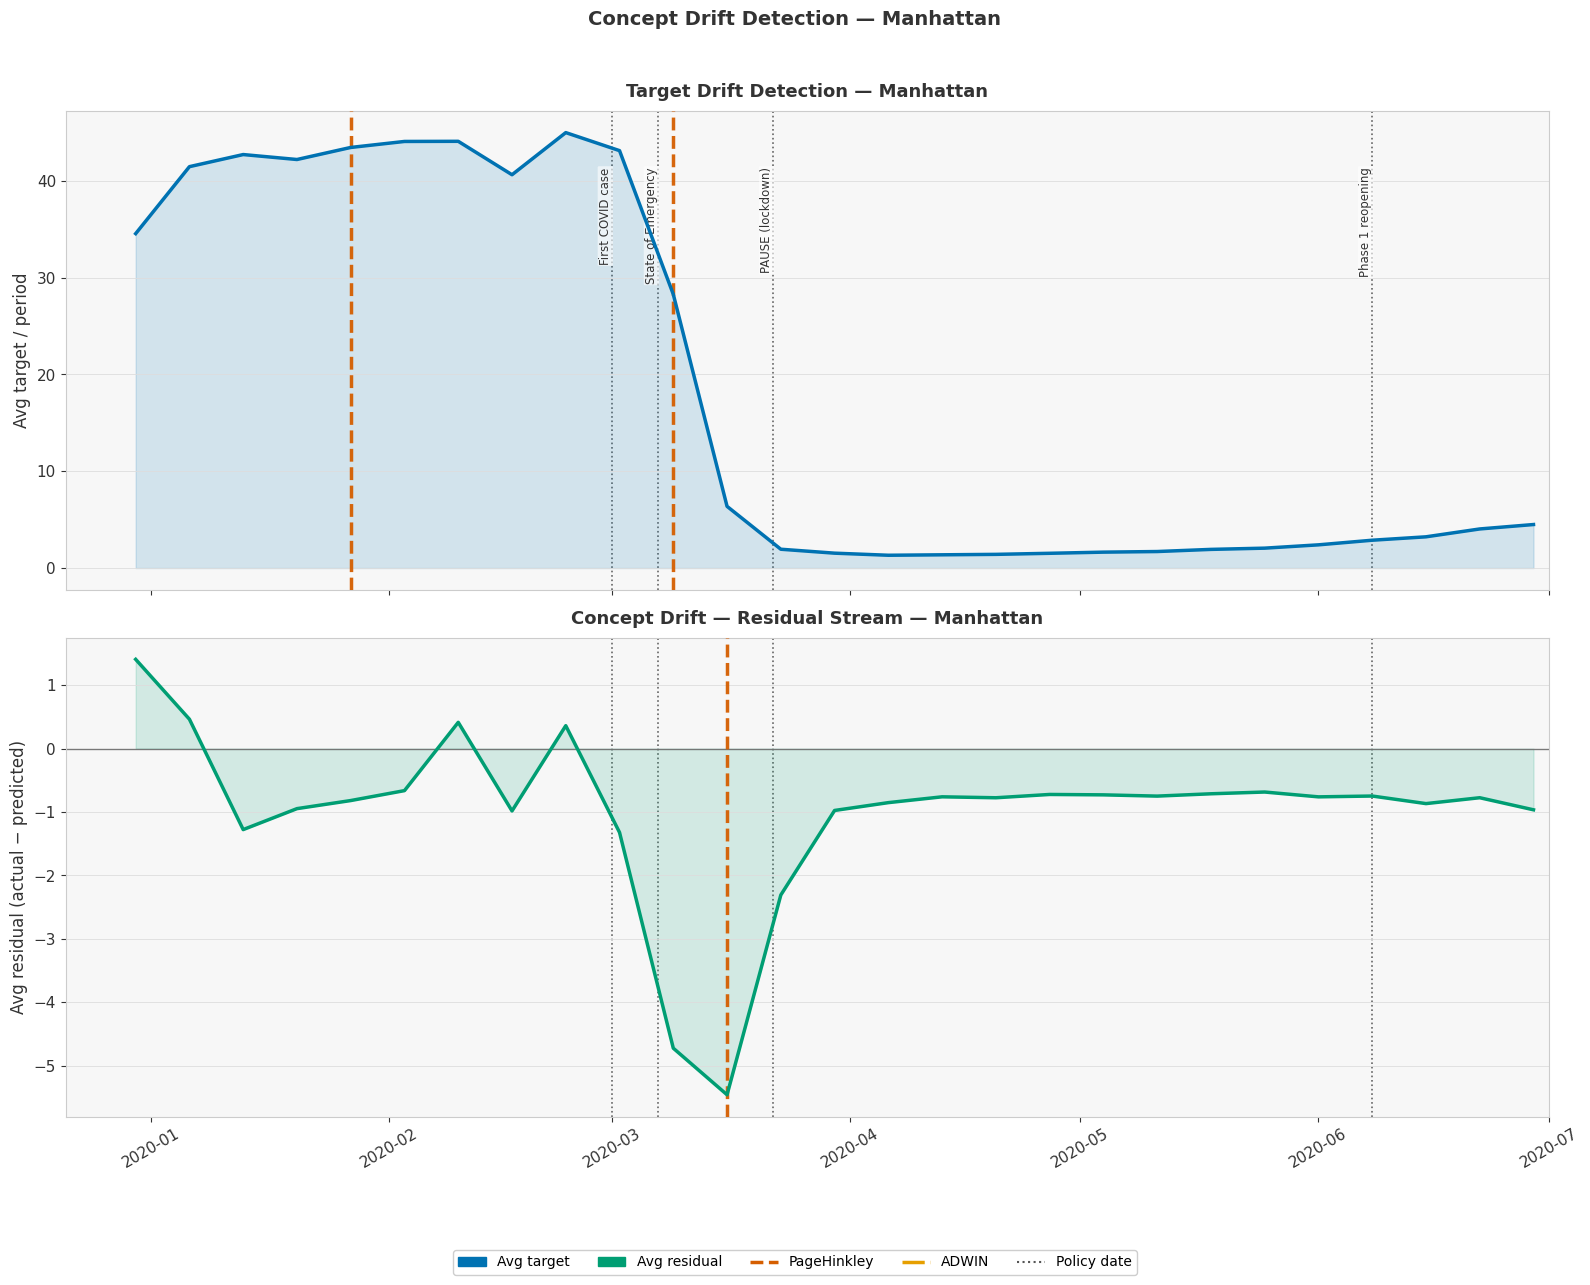

  Saved → /content/drive/MyDrive/ODATA57078/eda_outputs/concept_drift_zoomed_adwin.png


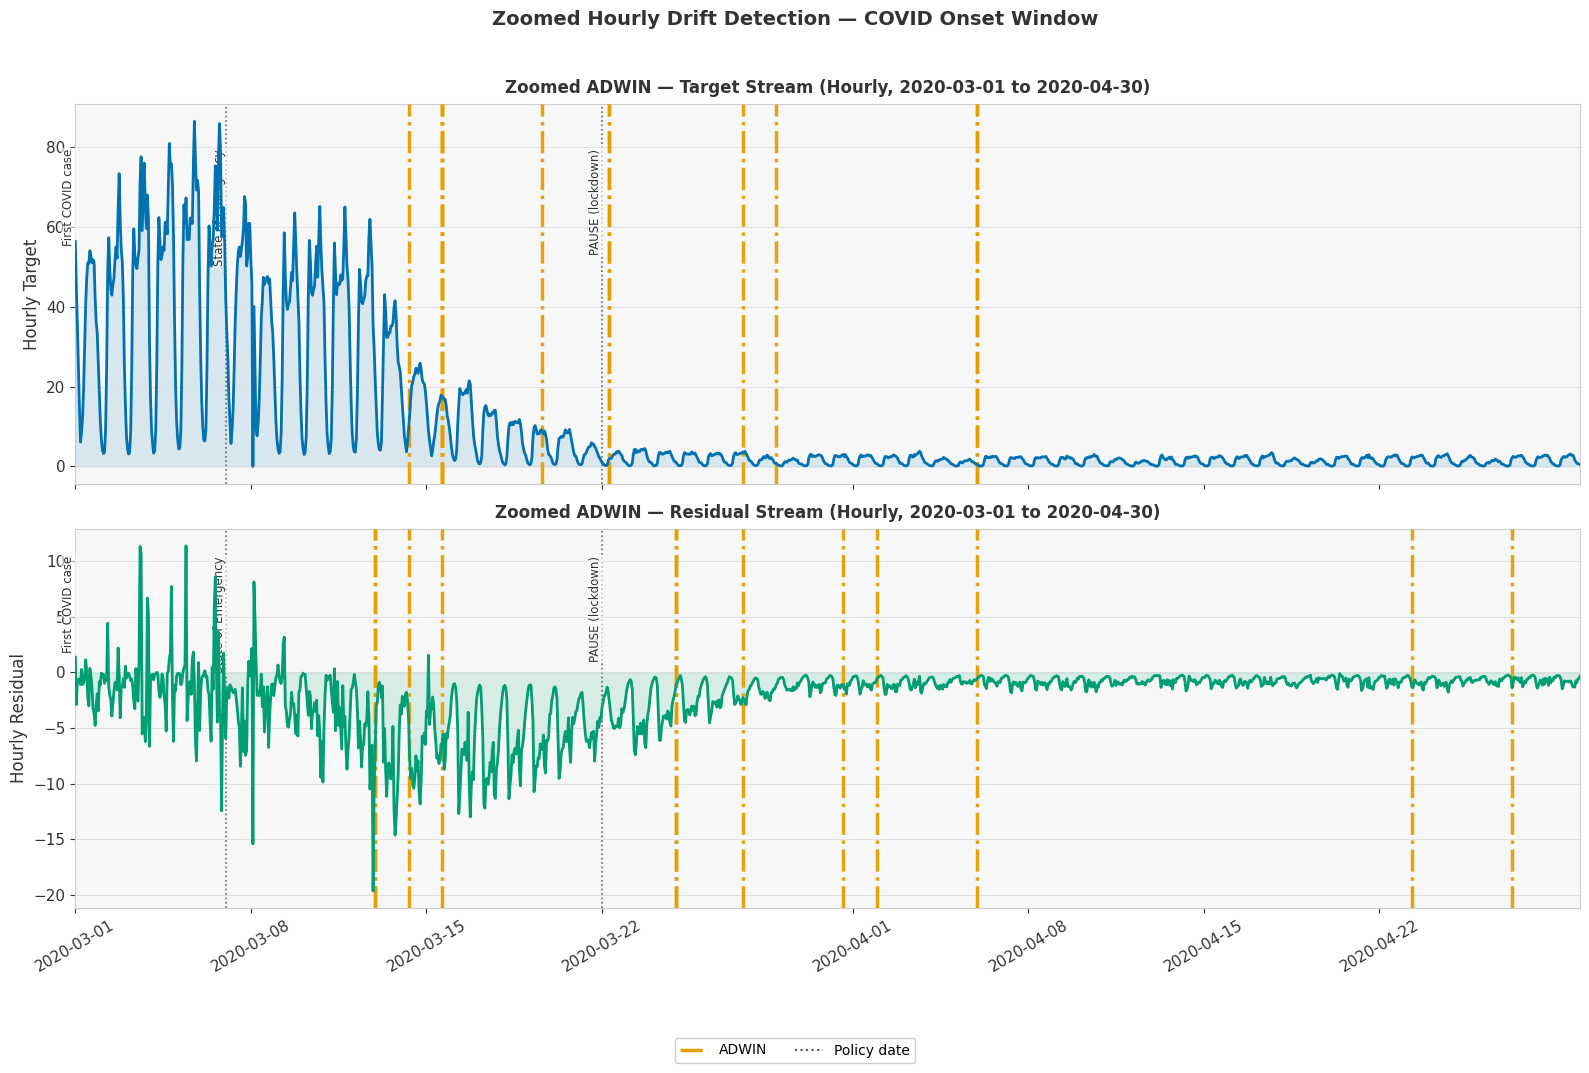

In [ ]:
# ── Run analysis (weekly + daily + zoomed ADWIN) ──────────────────────────────
results_weekly = run_concept_drift_analysis(
    monitoring_df  = monitoring_with_preds,
    policy_dates   = COVID_DATES,
    zoom_start     = '2020-03-01',   # zoomed hourly ADWIN around COVID onset
    zoom_end       = '2020-04-30',
    exclude_groups = {'EWR', 'Unknown'},
    streams        = [('trip_count', 'Target'), ('residual', 'Residual')],
)

# ── Overall plot (truncated at July) ─────────────────────────────────────────
plot_concept_drift(
    results      = results_weekly,
    policy_dates = COVID_DATES,
    plot_end     = '2020-07-01',
    title_suffix = 'Overall',
    save_dir     = OUT_DIR,
)

# ── Manhattan only ────────────────────────────────────────────────────────────
plot_concept_drift(
    results      = results_weekly,
    policy_dates = COVID_DATES,
    plot_end     = '2020-07-01',
    boroughs     = ['Manhattan'],
    title_suffix = 'Manhattan',
    save_dir     = OUT_DIR,
)

# ── Zoomed ADWIN hourly around COVID onset ────────────────────────────────────
plot_zoomed_adwin(
    results      = results_weekly,
    policy_dates = COVID_DATES,
    zoom_start   = '2020-03-01',
    zoom_end     = '2020-04-30',
    save_dir     = OUT_DIR,
)
